# Distillation Pipeline

In [1]:
selected_models = ["bert-base-uncased", "roberta-base", "distilbert-base-uncased"]

## 1. Setup

### Imports

In [2]:
import os
import time
import random
import copy
import json
from dataclasses import dataclass
from datetime import timedelta
from textDataset import TextDataset
from distillation import DistillationLoss, DistillationDataset
from distilledStudentModel import DistilledStudentModel
from featureClassifier import FeatureClassifier
from multi_teacher_distillation import (
    MultiTeacherDistillationLoss,
    make_multi_teacher_loader,
    train_multi_teacher_student,
)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### Config and Env Setup

In [52]:
# config and env setup
config_path = os.path.join(os.getcwd(), "distillation_config.json")
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

In [ ]:
# Configuration Parameters

SEED = int(config["seed"])

# feature extraction parameters
FEATURE_BATCH_SIZE = int(config["feature_extraction"]["batch_size"])
FEATURE_MAX_LENGTH = int(config["feature_extraction"]["max_length"])

LATENCY_BATCH_SIZE = int(config["evaluation"]["latency_batch_size"])

# training parameters
GRAD_CLIP = float(config["training"]["gradient_clip_norm"])
MIN_DELTA = float(config["training"]["min_delta"])
OPTIMIZER_NAME = str(config["training"]["optimizer"])

# directories
PIPELINE_METRICS_DIR = config["output"]["multi_teacher_output_dir"]
MULTI_TEACHER_PLOTS_DIR = config["output"].get("multi_teacher_plots_dir", "multi_teacher_plots")

# distillation configuration
distillation_config = config.get("distillation-multi-teacher", {})
DISTILLATION_ENABLED = config["distillation-multi-teacher"]["enabled"]
DISTILLATION_ALPHA = float(config["distillation-multi-teacher"]["alpha"])
DISTILLATION_TEMPERATURE = float(config["distillation-multi-teacher"]["temperature"])

# model-specific configurations
models = [m for m in config["models"] if m["model_id"] in selected_models]
model_configs = {
    model_name: cfg 
    for model_name, cfg in config["model_config"].items() if model_name in [m["name"] for m in models]}
print("Loaded model-specific configurations:")

for model_name, model_cfg in model_configs.items():
    print(f"\nModel: {model_name}")
    for param, value in model_cfg.items():
        print(f"  {param}: {value}")


# student model configuration
student_config = distillation_config.get("student_config", {})
STUDENT_HIDDEN_DIMS = student_config.get("hidden_dims", [256, 128])
STUDENT_DROPOUT = float(student_config.get("dropout", 0.3))
STUDENT_LR = float(student_config.get("learning_rate", 0.001))
STUDENT_BATCH_SIZE = int(student_config.get("batch_size", 64))
STUDENT_EPOCHS = int(student_config.get("epochs", 50))
STUDENT_PATIENCE = int(student_config.get("patience", 10))
DISTILLATION_OUTPUT_DIR = distillation_config.get("multi_teacher_output_dir", "distillation_metrics")

Loaded model-specific configurations:

Model: BERT
  epochs_options: [200]
  batch_size_options: [128]
  hidden_dims_options: [[512, 256, 128, 64]]
  dropout_options: [0.1]
  lr_options: [5e-05]
  n_splits: 5
  patience: 10
  show_epoch_progress: True

Model: RoBERTa
  epochs_options: [200]
  batch_size_options: [128]
  hidden_dims_options: [[512, 256, 128, 64]]
  dropout_options: [0.1]
  lr_options: [5e-05]
  n_splits: 5
  patience: 10
  show_epoch_progress: True

Model: DistilBERT
  epochs_options: [200]
  batch_size_options: [128]
  hidden_dims_options: [[512, 256, 128, 64]]
  dropout_options: [0.05]
  lr_options: [0.0003]
  n_splits: 5
  patience: 10
  show_epoch_progress: True


In [5]:
@dataclass
class ModelSpec:
    name: str
    model_id: str

In [6]:
model_specifications = [ModelSpec(model["name"], model["model_id"]) for model in models]

### Check GPU

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA version: 12.4


## 2. Data Loading and Preprocessing

In [8]:
# dataset = config["dataset"]["general_sentiment_analysis_dataset_old"]

# data_path = os.path.join(os.getcwd(), dataset["dataset_file_name"])

# # Try reading with explicit quoting to handle commas inside text fields
# df = pd.read_csv(data_path, quotechar='"', on_bad_lines='skip', encoding='utf-8')

# # Ensure 'label' column is of integer type based on the Sentiment column value, neutral is 1 , negative  is 0, 2 is positive
# # i already have sentiment column as 0 1 and 2. i need labels column as positive negative neutral based on the mapping i told u
# df["label"] = df["Sentiment"].map({0: "negative", 1: "neutral", 2: "positive"}).astype(str)


# print(df.columns.tolist())  # check what columns are detected
# print(df.shape)              # check how many rows loaded
# df.head()

In [9]:
# dataset = config["dataset"]["general_sentiment_analysis_dataset"]
# data_path = os.path.join(os.getcwd(), dataset["dataset_file_name"])

# df = pd.read_csv(data_path, quotechar='"', on_bad_lines='skip', encoding='utf-8')

# df = df.rename(columns={
#     df.columns[0]: "id",
#     "Comment": "text",
#     "Sentiment": "sentiment"
# })

# # Clean text column before anything else
# df = df.dropna(subset=["text"])
# df["text"] = df["text"].astype(str).str.strip()
# df = df[df["text"] != ""]
# df = df.reset_index(drop=True)

# df["label"] = df["sentiment"].map({0: "negative", 1: "neutral", 2: "positive"}).astype(str)

# df = df[["id", "text", "label", "sentiment"]]

# print(f"Dataset size after cleaning: {len(df)}")
# df.head()

In [12]:
dataset = config["dataset"]["general_sentiment_analysis_dataset"]

data_path = os.path.join(os.getcwd(), dataset["dataset_file_name_old"])
df = pd.read_json(data_path, lines=True)
df["label"] = df["label"].astype(int)
df.head()

,id,text,label,sentiment
0,9536,"Cooking microwave pizzas, yummy",2,positive
1,6135,Any plans of allowing sub tasks to show up in ...,1,neutral
2,17697,"I love the humor, I just reworded it. Like sa...",2,positive
3,14182,naw idk what ur talkin about,1,neutral
4,17840,That sucks to hear. I hate days like that,0,negative


## 3. Train/Validation/Test Split

In [13]:
texts = df["text"].astype(str).to_numpy()
labels = df["label"].to_numpy()

test_size = dataset["test_size"]
val_split = dataset["val_split"]

x_train, x_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=test_size, random_state=SEED, stratify=labels
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=val_split, random_state=SEED, stratify=y_temp
)

num_classes = len(np.unique(labels))
print(f"Train: {len(x_train)}, Val: {len(x_val)}, Test: {len(x_test)}")
print(f"Number of classes: {num_classes}")

Train: 21984, Val: 2748, Test: 2749
Number of classes: 3


## 4. Feature Extraction with Transformer Encoders

In [14]:
notebook_start_time = time.perf_counter()

In [15]:
def make_text_loader(texts, labels=None, batch_size=32):
    ds = TextDataset(texts, labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

### Feature Extractor

In [16]:
def prepare_tokenizer_and_model(model_id):
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device)

    if tokenizer.pad_token is None:
        fallback_token = tokenizer.eos_token or tokenizer.sep_token or tokenizer.unk_token
        if fallback_token is not None:
            tokenizer.pad_token = fallback_token
        else:
            tokenizer.add_special_tokens({"pad_token": "[PAD]"})
            model.resize_token_embeddings(len(tokenizer))

    model.config.pad_token_id = tokenizer.pad_token_id
    return tokenizer, model

In [17]:
def extract_features(model_id, texts, batch_size=32, max_length=256):
    """Extract CLS or pooled features using a transformer encoder."""
    tokenizer, model = prepare_tokenizer_and_model(model_id)
    model.eval()

    features = []
    loader = make_text_loader(texts, batch_size=batch_size)
    with torch.no_grad():
        for batch_texts in loader:
            encoded = tokenizer(
                list(batch_texts),
                max_length=max_length,
                padding=True,
                truncation=True,
                return_tensors="pt"
            ).to(device)

            outputs = model(**encoded)
            if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                batch_features = outputs.pooler_output
            else:
                batch_features = outputs.last_hidden_state[:, 0, :]

            features.append(batch_features.detach().cpu())

    features = torch.cat(features, dim=0)
    return features

### Extract Features

In [18]:
feature_cache = {}

In [19]:
for spec in model_specifications:
    print(f"=========Extracting features with {spec.name}...")
    print(f"Batch size: {FEATURE_BATCH_SIZE}, Max length: {FEATURE_MAX_LENGTH}")

    feature_cache[spec.name] = {
        "train": extract_features(
            spec.model_id,
            x_train,
            batch_size=FEATURE_BATCH_SIZE,
            max_length=FEATURE_MAX_LENGTH,
        ),
        "val": extract_features(
            spec.model_id,
            x_val,
            batch_size=FEATURE_BATCH_SIZE,
            max_length=FEATURE_MAX_LENGTH,
        ),
        "test": extract_features(
            spec.model_id,
            x_test,
            batch_size=FEATURE_BATCH_SIZE,
            max_length=FEATURE_MAX_LENGTH,
        ),
    }
    print(f"{spec.name} train feature shape: {feature_cache[spec.name]['train'].shape}")
    print(f"{spec.name} val feature shape: {feature_cache[spec.name]['val'].shape}")
    print(f"{spec.name} test feature shape: {feature_cache[spec.name]['test'].shape}")

=========Extracting features with BERT...
Batch size: 256, Max length: 256


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT train feature shape: torch.Size([21984, 768])
DistilBERT val feature shape: torch.Size([2748, 768])
DistilBERT test feature shape: torch.Size([2749, 768])


In [50]:
# save feature_cache to disk for later use
feature_cache_path = os.path.join(os.getcwd(), "multi-teacher-feature_cache.pt")
torch.save(feature_cache, feature_cache_path)

## 5. Neural Classifier

In [39]:
class FeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], int(self.labels[idx])

In [40]:
def make_feature_loader(features, labels, batch_size=64, shuffle=True):
    ds = FeatureDataset(features, labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

## 6. Detailed Metrics Tracking System

In [41]:
class MetricsTracker:
    """Track detailed training metrics for TensorBoard-style visualization."""
    
    def __init__(self, model_name: str):
        self.model_name = model_name
        self.history = {
            'epoch': [],
            'train_loss': [],
            'train_acc': [],
            'train_precision': [],
            'train_recall': [],
            'train_f1': [],
            'val_loss': [],
            'val_acc': [],
            'val_precision': [],
            'val_recall': [],
            'val_f1': [],
            'learning_rate': [],
            'epoch_time': []
        }
        
    def log_epoch(self, epoch: int, train_metrics: dict, val_metrics: dict, 
                  lr: float, epoch_time: float):
        """Log metrics for a single epoch."""
        self.history['epoch'].append(epoch)
        self.history['train_loss'].append(train_metrics['loss'])
        self.history['train_acc'].append(train_metrics['acc'])
        self.history['train_precision'].append(train_metrics['precision'])
        self.history['train_recall'].append(train_metrics['recall'])
        self.history['train_f1'].append(train_metrics['f1'])
        self.history['val_loss'].append(val_metrics['loss'])
        self.history['val_acc'].append(val_metrics['acc'])
        self.history['val_precision'].append(val_metrics['precision'])
        self.history['val_recall'].append(val_metrics['recall'])
        self.history['val_f1'].append(val_metrics['f1'])
        self.history['learning_rate'].append(lr)
        self.history['epoch_time'].append(epoch_time)
        
    def get_dataframe(self) -> pd.DataFrame:
        """Get history as DataFrame."""
        return pd.DataFrame(self.history)
    
    def save(self, filepath: str):
        """Save metrics to CSV."""
        df = self.get_dataframe()
        # df.to_csv(filepath, index=False)
        # print(f"Saved {self.model_name} training metrics to {filepath}")
        
    def plot_metrics(self, save_path: str = None):
        """Plot training metrics."""
        df = self.get_dataframe()
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle(f'{self.model_name} Training Metrics', fontsize=16, fontweight='bold')
        
        # Loss plot
        axes[0, 0].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o')
        axes[0, 0].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='s')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Accuracy plot
        axes[0, 1].plot(df['epoch'], df['train_acc'], label='Train Accuracy', marker='o')
        axes[0, 1].plot(df['epoch'], df['val_acc'], label='Val Accuracy', marker='s')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].set_title('Accuracy')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # F1 Score plot
        axes[1, 0].plot(df['epoch'], df['train_f1'], label='Train F1', marker='o')
        axes[1, 0].plot(df['epoch'], df['val_f1'], label='Val F1', marker='s')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('F1 Score')
        axes[1, 0].set_title('F1 Score')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Precision & Recall plot
        axes[1, 1].plot(df['epoch'], df['train_precision'], label='Train Precision', marker='o', linestyle='--')
        axes[1, 1].plot(df['epoch'], df['val_precision'], label='Val Precision', marker='s', linestyle='--')
        axes[1, 1].plot(df['epoch'], df['train_recall'], label='Train Recall', marker='^', linestyle=':')
        axes[1, 1].plot(df['epoch'], df['val_recall'], label='Val Recall', marker='v', linestyle=':')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].set_title('Precision & Recall')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            # plt.savefig(save_path, dpi=300, bbox_inches='tight')
            # print(f"Saved {self.model_name} training plot to {save_path}")
            pass
        
        plt.show()

## 7. Training and Evaluation Utilities

In [42]:
def compute_detailed_metrics(all_preds, all_labels):
    """Compute accuracy, precision, recall, and F1."""
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )
    return {
        'acc': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [43]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        if GRAD_CLIP > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
        all_preds.append(torch.argmax(logits, dim=1).detach().cpu())
        all_labels.append(y_batch.detach().cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    metrics = compute_detailed_metrics(all_preds, all_labels)
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics

In [44]:
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * x_batch.size(0)
            all_preds.append(torch.argmax(logits, dim=1).detach().cpu())
            all_labels.append(y_batch.detach().cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    metrics = compute_detailed_metrics(all_preds, all_labels)
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics

In [45]:
def make_optimizer(model, lr):
    opt = OPTIMIZER_NAME.strip().lower()
    if opt == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    if opt == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr)
    raise ValueError(f"Unsupported optimizer: {OPTIMIZER_NAME}")

In [46]:
def train_with_tracking(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    patience=5,
    min_delta=0.0,
    verbose=True,
    metrics_tracker=None
):
    """Train model with detailed metric tracking."""
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0
    epochs_since_improve = 0

    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()
        
        train_metrics = train_epoch(model, train_loader, optimizer, criterion)
        val_metrics = eval_epoch(model, val_loader, criterion)
        
        epoch_time = time.perf_counter() - epoch_start
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        # Log metrics
        if metrics_tracker:
            metrics_tracker.log_epoch(epoch, train_metrics, val_metrics, current_lr, epoch_time)
        
        if verbose:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['acc']:.4f} train_f1={train_metrics['f1']:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f} val_f1={val_metrics['f1']:.4f} | "
                f"time={epoch_time:.2f}s"
            )

        if val_metrics['acc'] > best_val_acc + min_delta:
            best_val_acc = val_metrics['acc']
            best_state = copy.deepcopy(model.state_dict())
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    return best_state, best_val_acc

In [47]:
def evaluate_model(model, loader):
    """Evaluate model and return all metrics."""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y_batch.numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    metrics = compute_detailed_metrics(all_preds, all_labels)
    return metrics

In [48]:
def measure_latency(model, features, labels, batch_size=256):
    """Measure inference latency."""
    model.eval()
    loader = make_feature_loader(features, labels, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for x_batch, _ in loader:
            _ = model(x_batch.to(device))
            break
        start = time.perf_counter()
        total = 0
        for x_batch, _ in loader:
            _ = model(x_batch.to(device))
            total += x_batch.size(0)
        end = time.perf_counter()
    return (end - start) / max(total, 1) * 1000

## 8. Train Models with Model-Specific Configurations

In [ ]:
# load the feature cache from disk
feature_cache_path = os.path.join(os.getcwd(), "multi-teacher-feature_cache.pt")
if os.path.exists(feature_cache_path):
    feature_cache = torch.load(feature_cache_path)
    print(f"Loaded feature cache from {feature_cache_path}")

Loaded feature cache from c:\Users\divya\OneDrive - rit.edu\RIT Spring24 MS CS\CAPSTONE\CODE\knowledge_distillation_sentiment_classification\feature_cache.pt


### Train Models

In [ ]:
# Create output directories for metrics and plots

os.makedirs(PIPELINE_METRICS_DIR, exist_ok=True)
os.makedirs(MULTI_TEACHER_PLOTS_DIR, exist_ok=True)

all_metrics_trackers = {}
final_results = {}
trained_teacher_models = {}  # stores trained model objects for use in distillation

In [33]:
# Train each teacher model with its specific configuration
for spec in model_specifications:
    model_name = spec.name
    print(f"\n{'='*80}")
    print(f"Training {model_name} with model-specific configuration")
    print(f"{'='*80}")


    # region - Get config and data loaders

    # Get model-specific config
    if model_name not in model_configs:
        print(f"WARNING: No config found for {model_name}, skipping...")
        continue
    
    model_cfg = model_configs[model_name]
    
    # Extract hyperparameters (taking first element from each _options list)
    epochs = model_cfg["epochs_options"][0]
    batch_size = model_cfg["batch_size_options"][0]
    hidden_dims = model_cfg["hidden_dims_options"][0]
    dropout = model_cfg["dropout_options"][0]
    lr = model_cfg["lr_options"][0]
    patience = model_cfg.get("patience", 5)
    
    print(f"Configuration:")
    print(f"  Epochs: {epochs}")
    print(f"  Batch Size: {batch_size}")
    print(f"  Hidden Dims: {hidden_dims}")
    print(f"  Dropout: {dropout}")
    print(f"  Learning Rate: {lr}")
    print(f"  Patience: {patience}")
    print()
    
    # Get features
    train_feats = feature_cache[model_name]["train"]
    val_feats = feature_cache[model_name]["val"]
    test_feats = feature_cache[model_name]["test"]
    input_dim = train_feats.shape[1]
    
    # Create data loaders
    train_loader = make_feature_loader(train_feats, y_train, batch_size=batch_size, shuffle=True)
    val_loader = make_feature_loader(val_feats, y_val, batch_size=batch_size, shuffle=False)
    test_loader = make_feature_loader(test_feats, y_test, batch_size=batch_size, shuffle=False)

    # endregion
    

    # region - Initialize model, optimizer, criterion, and metrics tracker

    # Initialize model
    model = FeatureClassifier(
        input_dim, num_classes, hidden_dims=hidden_dims, dropout=dropout
    ).to(device)
    
    optimizer = make_optimizer(model, lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # Initialize metrics tracker
    metrics_tracker = MetricsTracker(model_name)
    
    # Train model
    print(f"Training {model_name}...")
    training_start = time.perf_counter()
    
    best_state, best_val_acc = train_with_tracking(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=epochs,
        patience=patience,
        min_delta=MIN_DELTA,
        verbose=True,
        metrics_tracker=metrics_tracker
    )

    # endregion
    
    training_time = time.perf_counter() - training_start
    
    # Load best model weights and store for distillation use
    model.load_state_dict(best_state)
    trained_teacher_models[model_name] = model
    
    # Evaluate on test set
    print(f"\nEvaluating {model_name} on test set...")
    test_metrics = evaluate_model(model, test_loader)
    
    # Measure latency
    latency_ms = measure_latency(model, test_feats, y_test, batch_size=LATENCY_BATCH_SIZE)
    
    # Calculate model size
    params = sum(p.numel() for p in model.parameters())
    size_mb = params * 4 / 1e6
    
    # Store metrics tracker
    all_metrics_trackers[model_name] = metrics_tracker
    
    # Save training history
    history_path = os.path.join(PIPELINE_METRICS_DIR, f"{model_name}_training_history.csv")
    # metrics_tracker.save(history_path)
    
    # Store final results
    final_results[model_name] = {
        'config': {
            'epochs': epochs,
            'batch_size': batch_size,
            'hidden_dims': str(hidden_dims),
            'dropout': dropout,
            'lr': lr,
            'patience': patience
        },
        'best_val_acc': best_val_acc,
        'test_acc': test_metrics['acc'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'test_f1': test_metrics['f1'],
        'training_time_s': training_time,
        'params': params,
        'size_mb': size_mb,
        'latency_ms': latency_ms,
        'epochs_trained': len(metrics_tracker.history['epoch'])
    }
    
    print(f"\n{model_name} Results:")
    print(f"  Best Val Accuracy: {best_val_acc:.4f}")
    print(f"  Test Accuracy: {test_metrics['acc']:.4f}")
    print(f"  Test Precision: {test_metrics['precision']:.4f}")
    print(f"  Test Recall: {test_metrics['recall']:.4f}")
    print(f"  Test F1: {test_metrics['f1']:.4f}")
    print(f"  Training Time: {training_time:.2f}s")
    print(f"  Model Size: {size_mb:.2f} MB")
    print(f"  Latency: {latency_ms:.4f} ms")
    print(f"  Epochs Trained: {len(metrics_tracker.history['epoch'])}")


Training BERT with model-specific configuration
Configuration:
  Epochs: 200
  Batch Size: 128
  Hidden Dims: [512, 256, 128, 64]
  Dropout: 0.1
  Learning Rate: 5e-05
  Patience: 10

Training BERT...
Epoch   1/200 | train_loss=1.0942 train_acc=0.3691 train_f1=0.3000 | val_loss=1.0901 val_acc=0.3846 val_f1=0.2137 | time=1.31s
Epoch   2/200 | train_loss=1.0812 train_acc=0.4002 train_f1=0.3005 | val_loss=1.0553 val_acc=0.4541 val_f1=0.3862 | time=0.94s
Epoch   3/200 | train_loss=1.0203 train_acc=0.4706 train_f1=0.4521 | val_loss=0.9653 val_acc=0.5106 val_f1=0.5004 | time=0.97s
Epoch   4/200 | train_loss=0.9660 train_acc=0.5126 train_f1=0.5089 | val_loss=0.9269 val_acc=0.5357 val_f1=0.5172 | time=1.14s
Epoch   5/200 | train_loss=0.9356 train_acc=0.5319 train_f1=0.5310 | val_loss=0.9110 val_acc=0.5400 val_f1=0.5259 | time=0.85s
Epoch   6/200 | train_loss=0.9209 train_acc=0.5443 train_f1=0.5435 | val_loss=0.8913 val_acc=0.5724 val_f1=0.5675 | time=1.05s
Epoch   7/200 | train_loss=0.9114 tr

In [51]:
# save the trained model into a file for later use in distillation into a directory named "models"
os.makedirs("multi-teacher-models", exist_ok=True)
for model_name, model in trained_teacher_models.items():
    model_path = os.path.join("multi-teacher-models", f"{model_name}_teacher_model.pt")
    torch.save(model.state_dict(), model_path)
    print(f"Saved trained {model_name} teacher model to {model_path}")

Saved trained BERT teacher model to multi-teacher-models\BERT_teacher_model.pt
Saved trained RoBERTa teacher model to multi-teacher-models\RoBERTa_teacher_model.pt
Saved trained DistilBERT teacher model to multi-teacher-models\DistilBERT_teacher_model.pt


### Visualize Training Metrics

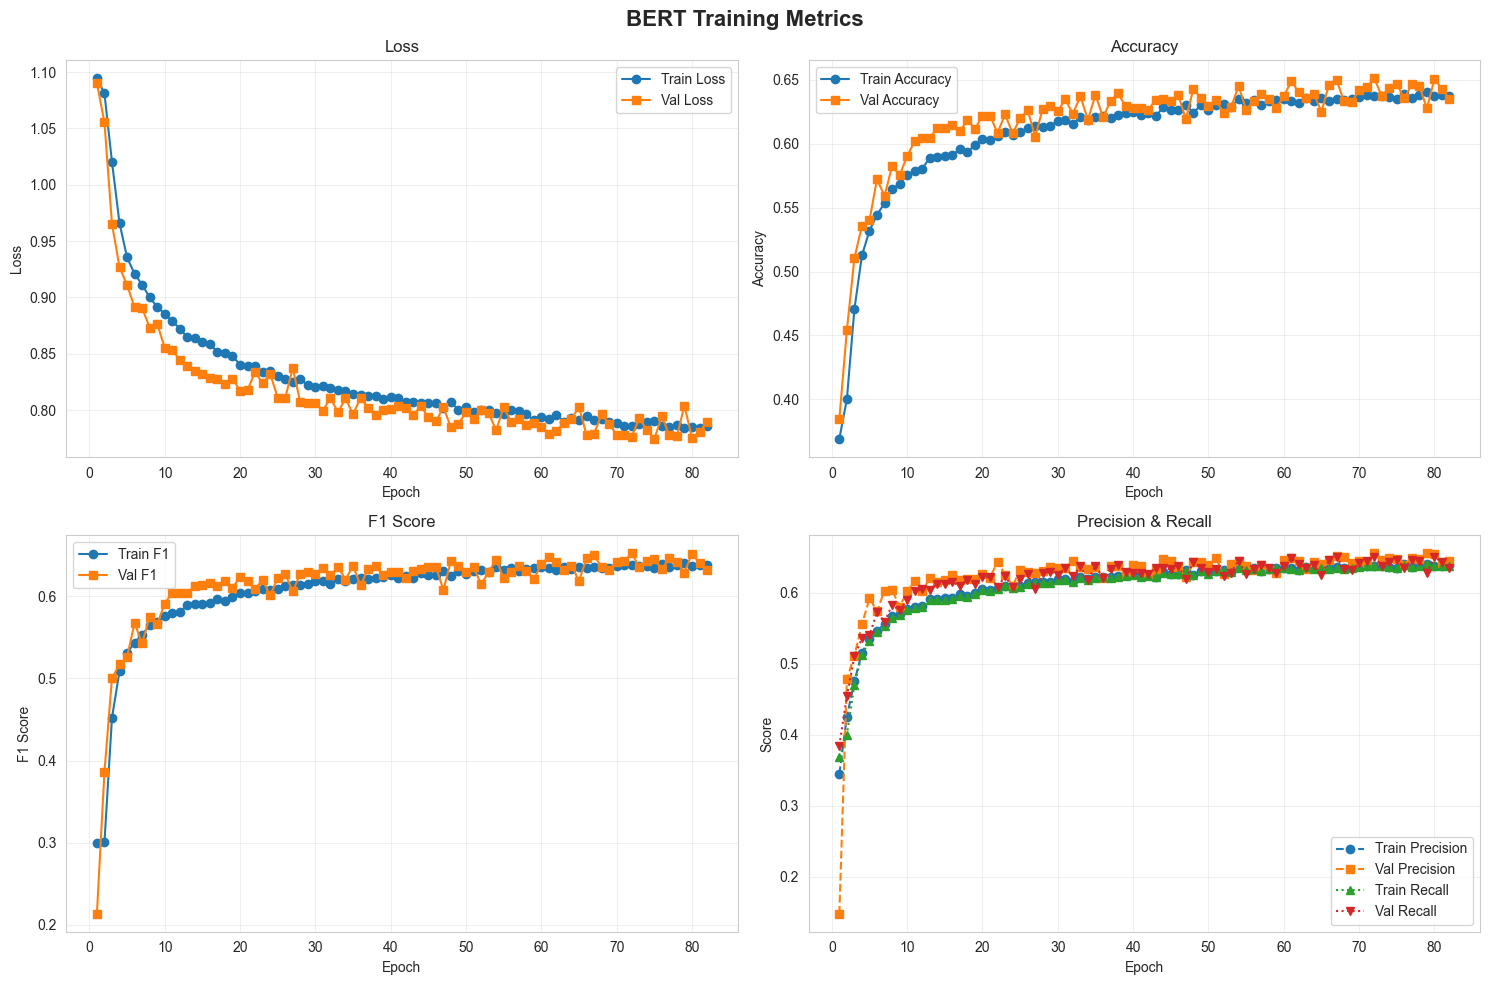

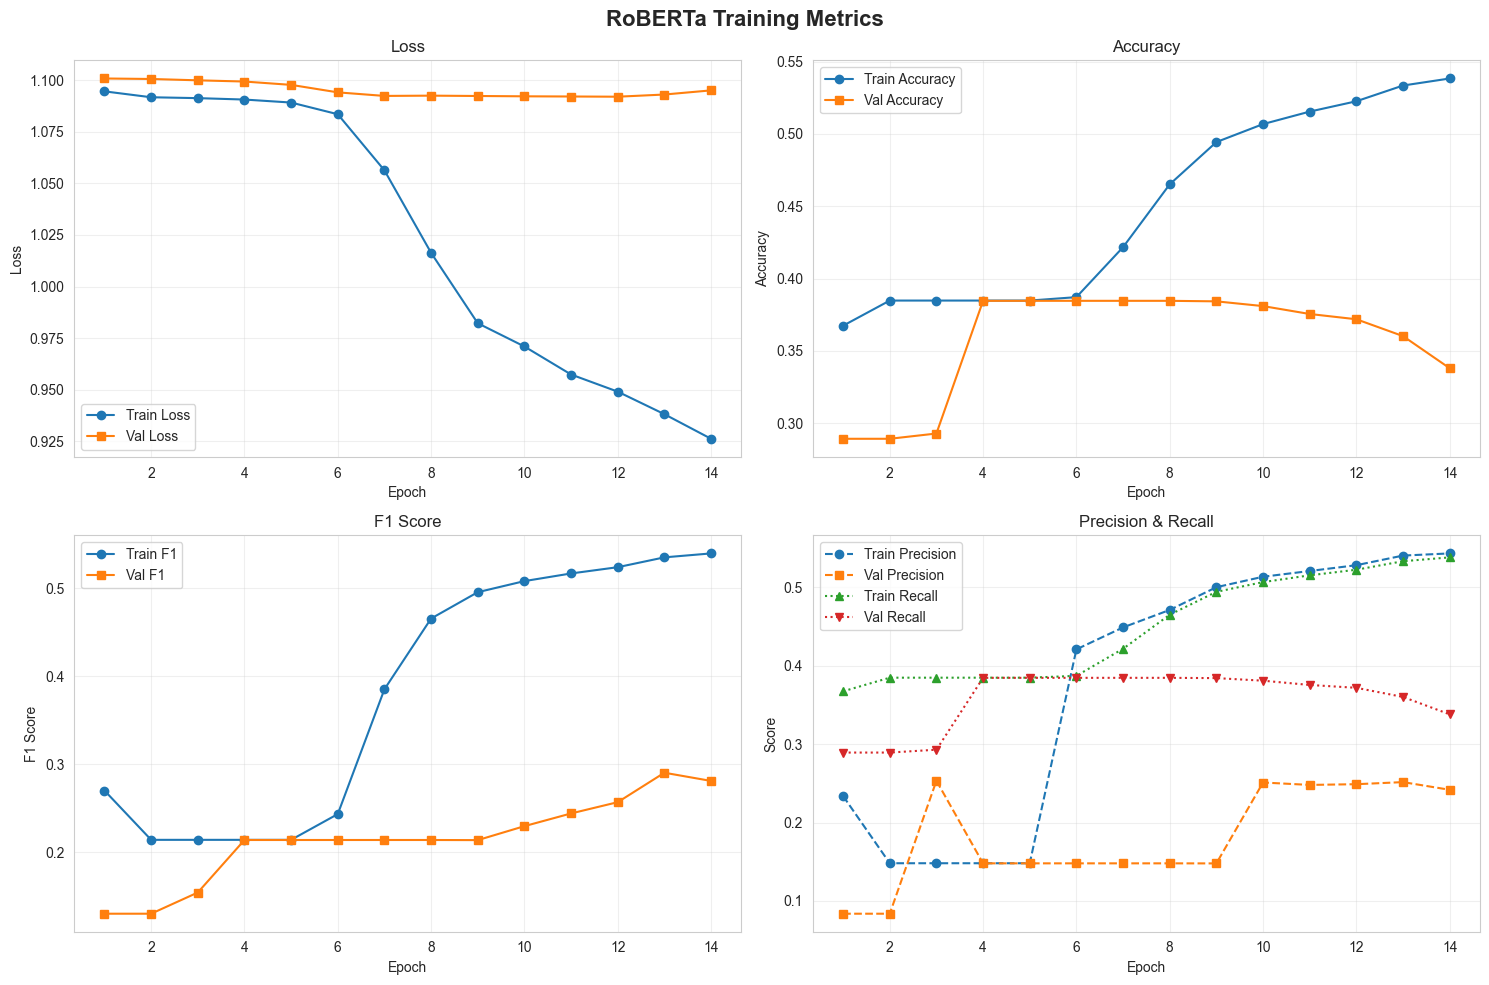

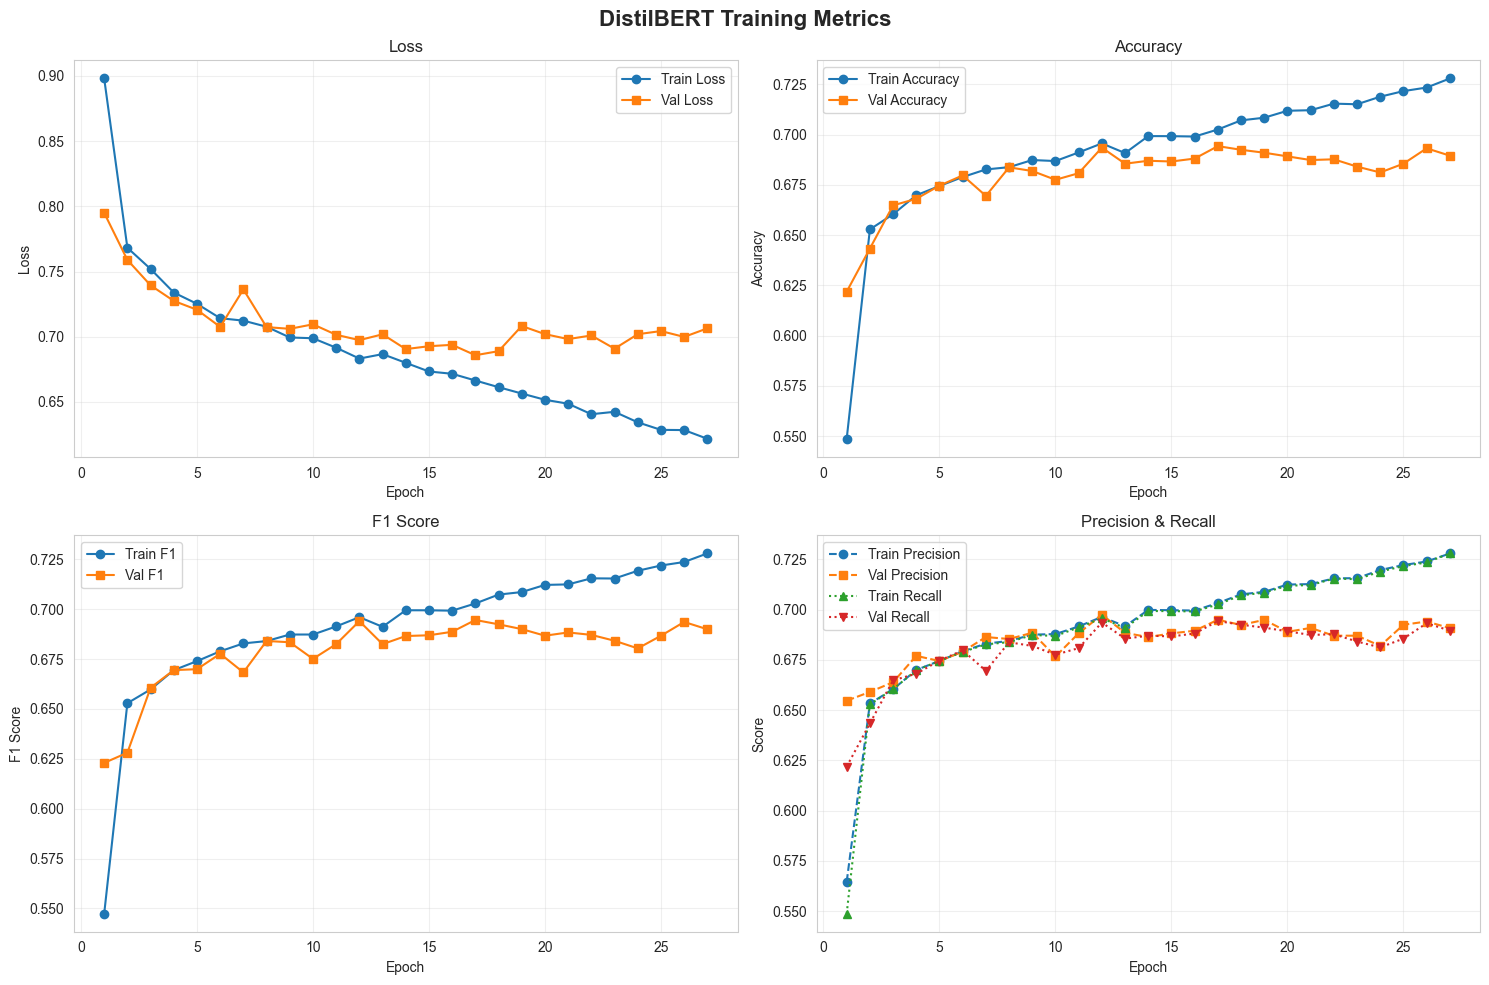

In [ ]:
# Plot training metrics for each model
for model_name, tracker in all_metrics_trackers.items():
    plot_path = os.path.join(PIPELINE_METRICS_DIR, f"{model_name}_training_plot.png")
    tracker.plot_metrics(save_path=plot_path)

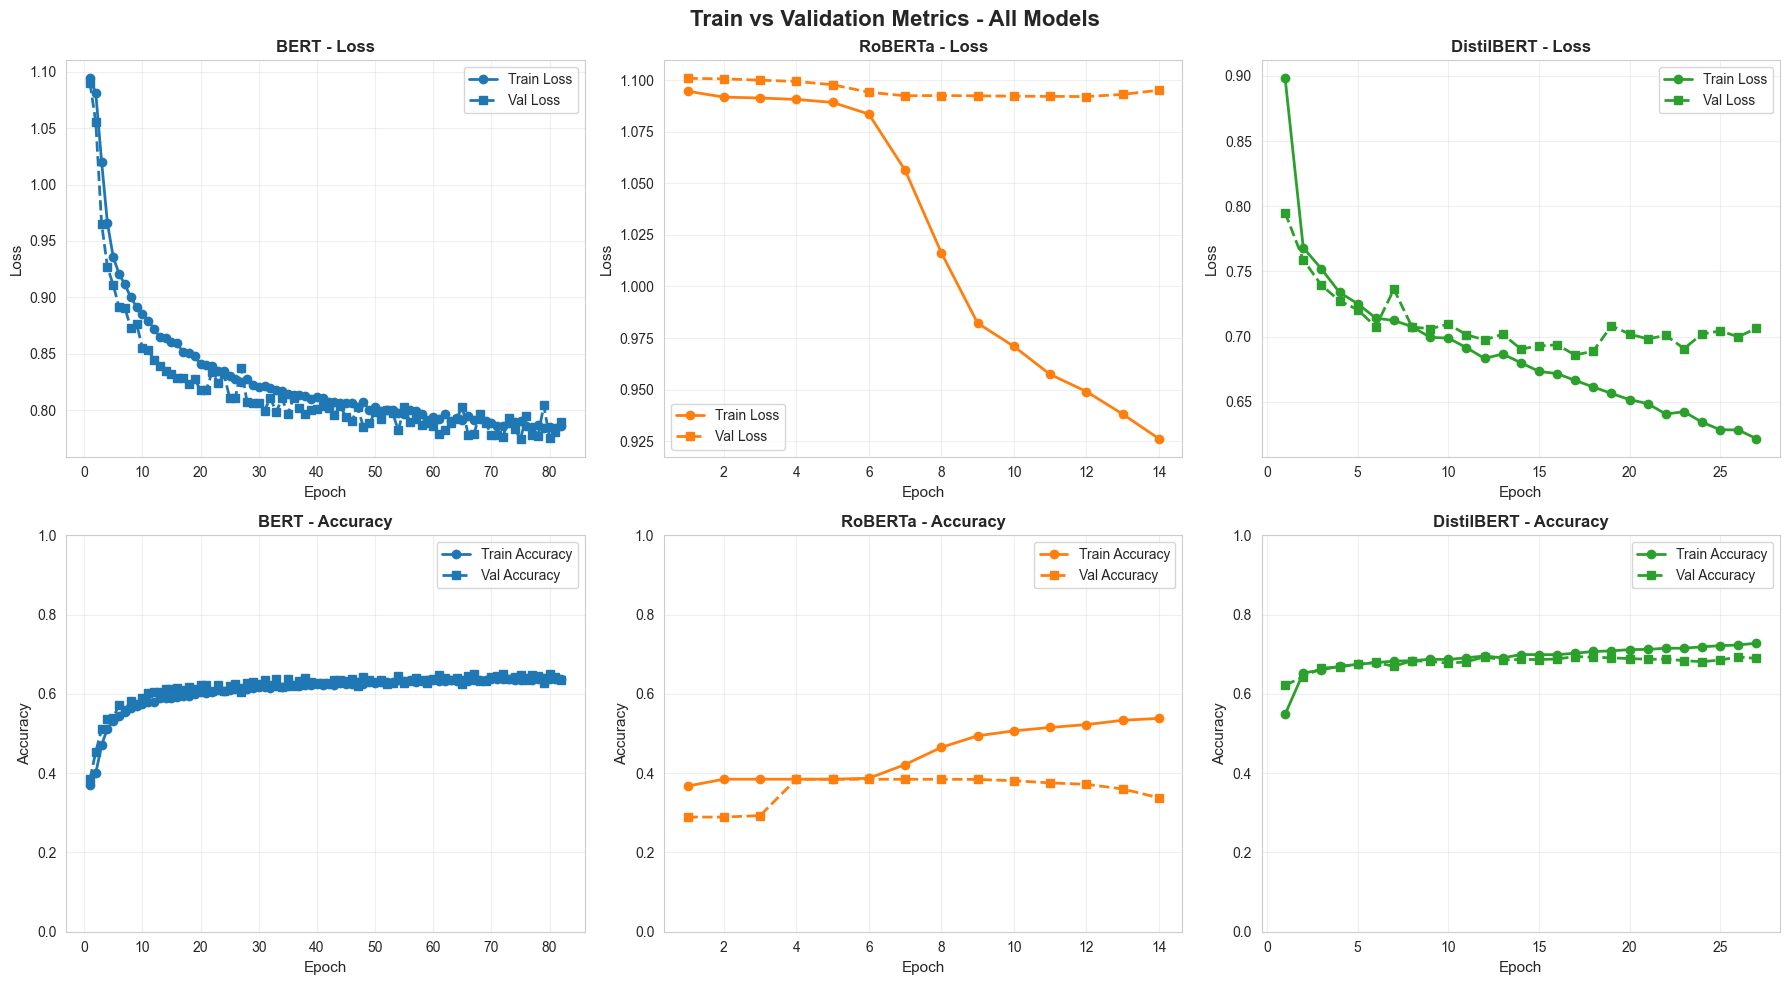

In [ ]:
# Create train/val accuracy and loss curves for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Train vs Validation Metrics - All Models', fontsize=16, fontweight='bold')

model_names = list(all_metrics_trackers.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for col_idx, model_name in enumerate(model_names):
    tracker = all_metrics_trackers[model_name]
    df = tracker.get_dataframe()
    
    # Loss plot
    axes[0, col_idx].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o', color=colors[col_idx], linestyle='-', linewidth=2)
    axes[0, col_idx].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='s', color=colors[col_idx], linestyle='--', linewidth=2)
    axes[0, col_idx].set_xlabel('Epoch', fontsize=11)
    axes[0, col_idx].set_ylabel('Loss', fontsize=11)
    axes[0, col_idx].set_title(f'{model_name} - Loss', fontsize=12, fontweight='bold')
    axes[0, col_idx].legend(fontsize=10)
    axes[0, col_idx].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1, col_idx].plot(df['epoch'], df['train_acc'], label='Train Accuracy', marker='o', color=colors[col_idx], linestyle='-', linewidth=2)
    axes[1, col_idx].plot(df['epoch'], df['val_acc'], label='Val Accuracy', marker='s', color=colors[col_idx], linestyle='--', linewidth=2)
    axes[1, col_idx].set_xlabel('Epoch', fontsize=11)
    axes[1, col_idx].set_ylabel('Accuracy', fontsize=11)
    axes[1, col_idx].set_title(f'{model_name} - Accuracy', fontsize=12, fontweight='bold')
    axes[1, col_idx].legend(fontsize=10)
    axes[1, col_idx].grid(True, alpha=0.3)
    axes[1, col_idx].set_ylim([0, 1.0])

plt.tight_layout()

# Save combined plot for all models
# train_val_plot_path = os.path.join(PIPELINE_METRICS_DIR, "all_models_train_val_curves.png")
# plt.savefig(train_val_plot_path, dpi=300, bbox_inches='tight')
# print(f"Saved train/val curves plot to {train_val_plot_path}")
# plt.show()

## 9. Compare Models

In [54]:
# Create summary comparison
results_df = pd.DataFrame(final_results).T
if len(results_df) > 0:
    results_df = results_df.sort_values('test_f1', ascending=False)

print("\n" + "="*80)
print("COMPARISON OF TEACHER MODELS")
print("="*80)
print(results_df[['test_acc', 'test_precision', 'test_recall', 'test_f1', 'training_time_s', 'size_mb', 'latency_ms']])


COMPARISON OF TEACHER MODELS
            test_acc test_precision test_recall   test_f1 training_time_s  \
DistilBERT  0.699891       0.703029    0.699891  0.700953       28.704808   
BERT        0.640233       0.648345    0.640233  0.641887       82.146932   
RoBERTa     0.384867       0.148123    0.384867  0.213916       13.946576   

             size_mb latency_ms  
DistilBERT  2.265612   0.019697  
BERT        2.265612    0.00831  
RoBERTa     2.265612   0.013576  


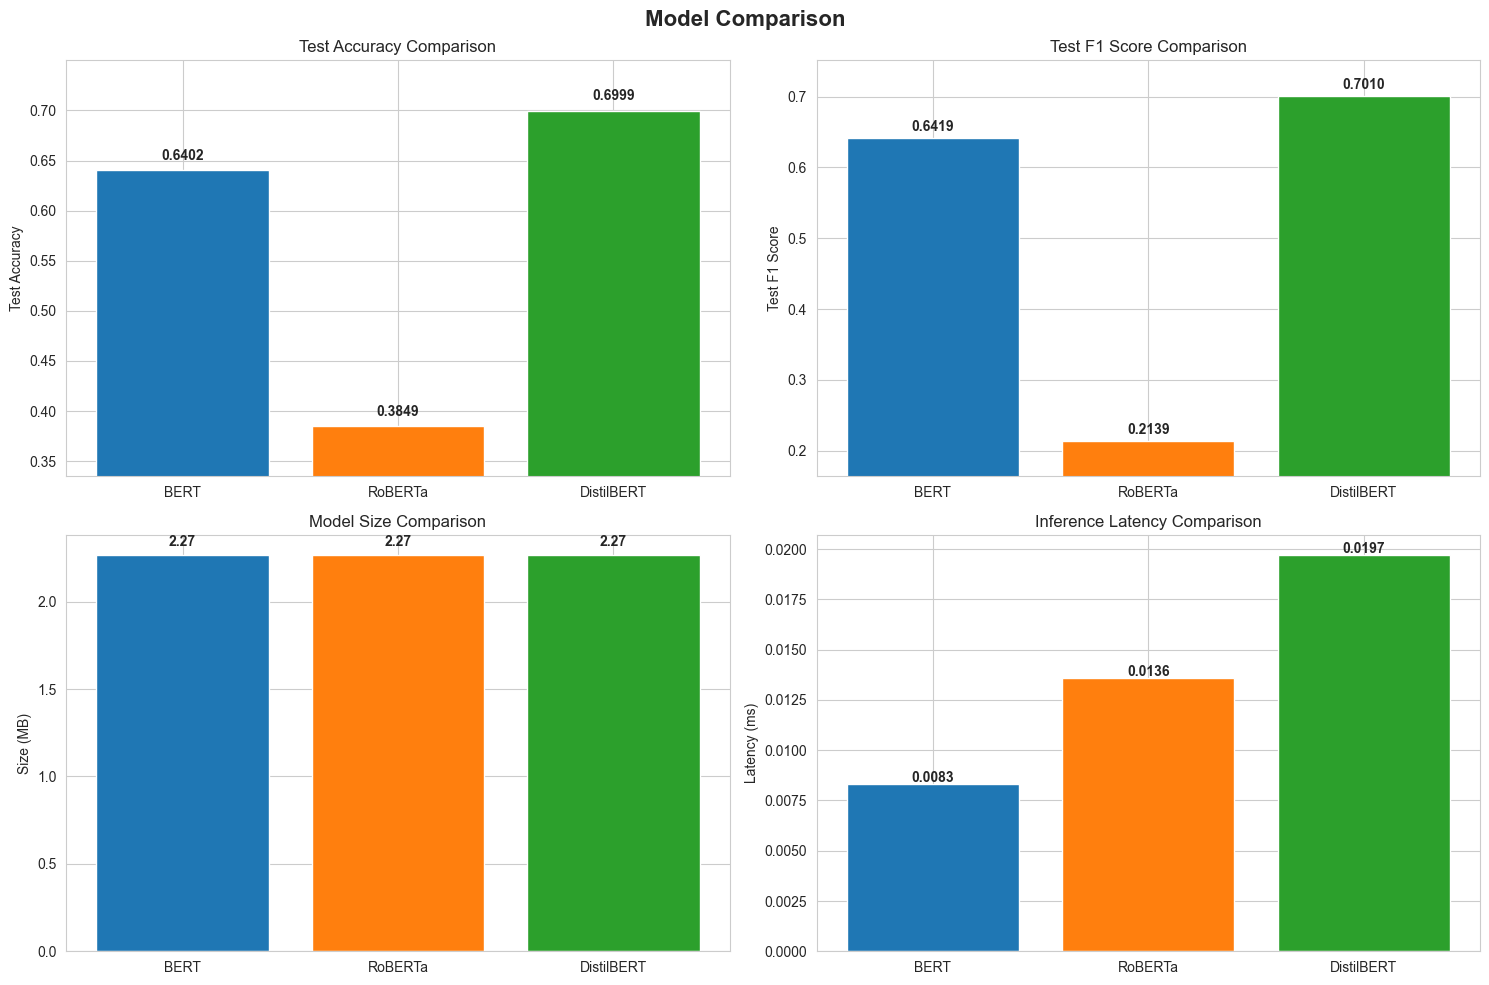

In [ ]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')

models = list(final_results.keys())
test_accs = [final_results[m]['test_acc'] for m in models]
test_f1s = [final_results[m]['test_f1'] for m in models]
sizes = [final_results[m]['size_mb'] for m in models]
latencies = [final_results[m]['latency_ms'] for m in models]

# Test Accuracy
axes[0, 0].bar(models, test_accs, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].set_ylim([min(test_accs) - 0.05, max(test_accs) + 0.05])
for i, v in enumerate(test_accs):
    axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Test F1 Score
axes[0, 1].bar(models, test_f1s, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 1].set_ylabel('Test F1 Score')
axes[0, 1].set_title('Test F1 Score Comparison')
axes[0, 1].set_ylim([min(test_f1s) - 0.05, max(test_f1s) + 0.05])
for i, v in enumerate(test_f1s):
    axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Model Size
axes[1, 0].bar(models, sizes, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_ylabel('Size (MB)')
axes[1, 0].set_title('Model Size Comparison')
for i, v in enumerate(sizes):
    axes[1, 0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Latency
axes[1, 1].bar(models, latencies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 1].set_ylabel('Latency (ms)')
axes[1, 1].set_title('Inference Latency Comparison')
for i, v in enumerate(latencies):
    axes[1, 1].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
# comparison_plot_path = os.path.join(MULTI_TEACHER_PLOTS_DIR, "model_comparison.png")
# plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
# print(f"Saved model comparison plot to {comparison_plot_path}")
plt.show()

## 10. Distillation

### Feature Based Distillation

#### Intermediate layer extractor

In [55]:
def extract_teacher_intermediate_features(teacher_model, data_loader):
    """
    Extract intermediate features from a trained teacher model.
    Args:
        teacher_model: Trained FeatureClassifier model
        data_loader: DataLoader containing input features
    Returns:
        List of intermediate feature tensors for each layer
    """
    teacher_model.eval()
    all_intermediates = []
    
    with torch.no_grad():
        for x_batch, _ in data_loader:
            x_batch = x_batch.to(device)
            
            # Extract intermediate features by hooking into the network
            intermediates = []
            h = x_batch
            
            # Go through the sequential layers
            for i, layer in enumerate(teacher_model.net):
                h = layer(h)
                # Store activations after ReLU layers (before dropout)
                if isinstance(layer, nn.ReLU):
                    intermediates.append(h.detach().cpu())
            
            if len(all_intermediates) == 0:
                all_intermediates = [[] for _ in range(len(intermediates))]
            
            for idx, feat in enumerate(intermediates):
                all_intermediates[idx].append(feat)
    
    # Concatenate all batches for each layer
    all_intermediates = [torch.cat(layer_feats, dim=0) for layer_feats in all_intermediates]
    
    return all_intermediates


In [56]:
print("Extracting intermediate features and logits from trained teacher models...")
teacher_intermediate_features = {}
teacher_logits_cache = {}

for model_name in final_results.keys():
    print(f"\nProcessing {model_name}...")
    
    # Get the trained model configuration
    model_cfg = model_configs[model_name]
    hidden_dims = model_cfg["hidden_dims_options"][0]
    batch_size = model_cfg["batch_size_options"][0]
    
    train_feats = feature_cache[model_name]["train"]
    val_feats = feature_cache[model_name]["val"]
    test_feats = feature_cache[model_name]["test"]
    
    # Create data loaders
    train_loader = make_feature_loader(train_feats, y_train, batch_size=batch_size, shuffle=False)
    val_loader = make_feature_loader(val_feats, y_val, batch_size=batch_size, shuffle=False)
    test_loader = make_feature_loader(test_feats, y_test, batch_size=batch_size, shuffle=False)
    
    # Use the trained teacher model stored during teacher training
    teacher_model = trained_teacher_models[model_name]
    teacher_model.eval()
    print(f"  Using trained teacher model with hidden_dims={hidden_dims}")
    
    # Extract intermediate features from training, validation, and test sets
    teacher_intermediate_features[model_name] = {
        'train': extract_teacher_intermediate_features(teacher_model, train_loader),
        'val': extract_teacher_intermediate_features(teacher_model, val_loader),
        'test': extract_teacher_intermediate_features(teacher_model, test_loader)
    }
    
    print(f"  Extracted {len(teacher_intermediate_features[model_name]['train'])} intermediate layers")
    for idx, layer_feats in enumerate(teacher_intermediate_features[model_name]['train']):
        print(f"    Layer {idx}: {layer_feats.shape}")
    
    # Extract teacher logits for logits-based KD (FeatureClassifier doesn't have return_intermediate)
    print(f"  Extracting teacher logits...")
    teacher_logits_cache[model_name] = {}
    for split_name, loader in [('train', train_loader), ('val', val_loader), ('test', test_loader)]:
        logits_list = []
        with torch.no_grad():
            for x_batch, y_batch in loader:
                x_batch = x_batch.to(device)
                logits = teacher_model(x_batch)  # FeatureClassifier returns logits directly
                logits_list.append(logits.cpu())
        teacher_logits_cache[model_name][split_name] = torch.cat(logits_list, dim=0)
        print(f"    {split_name} logits shape: {teacher_logits_cache[model_name][split_name].shape}")

print("\nIntermediate feature and logits extraction complete!")


Extracting intermediate features and logits from trained teacher models...

Processing BERT...
  Using trained teacher model with hidden_dims=[512, 256, 128, 64]
  Extracted 0 intermediate layers
  Extracting teacher logits...
    train logits shape: torch.Size([21984, 3])
    val logits shape: torch.Size([2748, 3])
    test logits shape: torch.Size([2749, 3])

Processing RoBERTa...
  Using trained teacher model with hidden_dims=[512, 256, 128, 64]
  Extracted 0 intermediate layers
  Extracting teacher logits...
    train logits shape: torch.Size([21984, 3])
    val logits shape: torch.Size([2748, 3])
    test logits shape: torch.Size([2749, 3])

Processing DistilBERT...
  Using trained teacher model with hidden_dims=[512, 256, 128, 64]
  Extracted 0 intermediate layers
  Extracting teacher logits...
    train logits shape: torch.Size([21984, 3])
    val logits shape: torch.Size([2748, 3])
    test logits shape: torch.Size([2749, 3])

Intermediate feature and logits extraction complete

#### Distillation functions

In [57]:
class DistillationDatasetWithLogits(Dataset):
    """Dataset that provides input features, labels, teacher intermediate features, and teacher logits."""
    def __init__(self, features, labels, teacher_intermediates, teacher_logits=None):
        self.features = features
        self.labels = labels
        self.teacher_intermediates = teacher_intermediates
        self.teacher_logits = teacher_logits
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        teacher_feats = [layer_feat[idx] for layer_feat in self.teacher_intermediates]
        if self.teacher_logits is not None:
            return self.features[idx], int(self.labels[idx]), teacher_feats, self.teacher_logits[idx]
        return self.features[idx], int(self.labels[idx]), teacher_feats, None


def make_distillation_loader(features, labels, teacher_intermediates, teacher_logits=None, batch_size=64, shuffle=True):
    """Create DataLoader for distillation training with optional teacher logits."""
    ds = DistillationDatasetWithLogits(features, labels, teacher_intermediates, teacher_logits)
    
    def collate_fn(batch):
        features = torch.stack([item[0] for item in batch])
        labels = torch.tensor([item[1] for item in batch])
        # Stack teacher features for each layer
        teacher_feats = []
        num_layers = len(batch[0][2])
        for layer_idx in range(num_layers):
            layer_batch = torch.stack([item[2][layer_idx] for item in batch])
            teacher_feats.append(layer_batch)
        
        # Include teacher logits if provided
        teacher_logits_batch = None
        if batch[0][3] is not None:
            teacher_logits_batch = torch.stack([item[3] for item in batch])
        
        return features, labels, teacher_feats, teacher_logits_batch
    
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)

In [58]:
def train_distillation_epoch(student_model, loader, optimizer, distill_criterion):
    """Train one epoch with feature-based distillation and logits KD."""
    student_model.train()
    total_loss = 0.0
    total_task_loss = 0.0
    total_distill_loss = 0.0
    all_preds = []
    all_labels = []
    
    for batch_data in loader:
        # Handle both new format (with teacher logits) and old format (without)
        if len(batch_data) == 4:
            x_batch, y_batch, teacher_feats, teacher_logits = batch_data
        else:
            x_batch, y_batch, teacher_feats = batch_data
            teacher_logits = None
        
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        teacher_feats = [feat.to(device) for feat in teacher_feats]
        if teacher_logits is not None:
            teacher_logits = teacher_logits.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass with intermediate features
        student_logits, student_feats = student_model(x_batch, return_intermediate=True)
        
        # Compute distillation loss (now includes logits KD if teacher_logits provided)
        loss, task_loss, distill_loss = distill_criterion(
            student_logits, student_feats, teacher_feats, y_batch, teacher_logits=teacher_logits
        )
        
        loss.backward()
        if GRAD_CLIP > 0:
            torch.nn.utils.clip_grad_norm_(student_model.parameters(), GRAD_CLIP)
        optimizer.step()
        
        total_loss += loss.item() * x_batch.size(0)
        total_task_loss += task_loss.item() * x_batch.size(0)
        total_distill_loss += distill_loss.item() * x_batch.size(0)
        
        all_preds.append(torch.argmax(student_logits, dim=1).detach().cpu())
        all_labels.append(y_batch.detach().cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    metrics = compute_detailed_metrics(all_preds, all_labels)
    metrics['loss'] = total_loss / len(loader.dataset)
    metrics['task_loss'] = total_task_loss / len(loader.dataset)
    metrics['distill_loss'] = total_distill_loss / len(loader.dataset)
    
    return metrics

In [59]:
def eval_distillation_epoch(student_model, loader, distill_criterion):
    """Evaluate student model with distillation loss and logits KD."""
    student_model.eval()
    total_loss = 0.0
    total_task_loss = 0.0
    total_distill_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_data in loader:
            # Handle both new format (with teacher logits) and old format (without)
            if len(batch_data) == 4:
                x_batch, y_batch, teacher_feats, teacher_logits = batch_data
            else:
                x_batch, y_batch, teacher_feats = batch_data
                teacher_logits = None
            
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            teacher_feats = [feat.to(device) for feat in teacher_feats]
            if teacher_logits is not None:
                teacher_logits = teacher_logits.to(device)
            
            student_logits, student_feats = student_model(x_batch, return_intermediate=True)
            
            # Compute distillation loss (now includes logits KD if teacher_logits provided)
            loss, task_loss, distill_loss = distill_criterion(
                student_logits, student_feats, teacher_feats, y_batch, teacher_logits=teacher_logits
            )
            
            total_loss += loss.item() * x_batch.size(0)
            total_task_loss += task_loss.item() * x_batch.size(0)
            total_distill_loss += distill_loss.item() * x_batch.size(0)
            
            all_preds.append(torch.argmax(student_logits, dim=1).detach().cpu())
            all_labels.append(y_batch.detach().cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    metrics = compute_detailed_metrics(all_preds, all_labels)
    metrics['loss'] = total_loss / len(loader.dataset)
    metrics['task_loss'] = total_task_loss / len(loader.dataset)
    metrics['distill_loss'] = total_distill_loss / len(loader.dataset)
    
    return metrics

In [60]:
def train_distilled_student(
    student_model,
    train_loader,
    val_loader,
    optimizer,
    distill_criterion,
    epochs,
    patience=5,
    min_delta=0.0,
    verbose=True
):
    """Train student model with feature-based distillation."""
    best_state = copy.deepcopy(student_model.state_dict())
    best_val_acc = -1.0
    epochs_since_improve = 0
    history = []
    
    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()
        
        train_metrics = train_distillation_epoch(student_model, train_loader, optimizer, distill_criterion)
        val_metrics = eval_distillation_epoch(student_model, val_loader, distill_criterion)
        
        epoch_time = time.perf_counter() - epoch_start
        
        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_task_loss': train_metrics['task_loss'],
            'train_distill_loss': train_metrics['distill_loss'],
            'train_acc': train_metrics['acc'],
            'val_loss': val_metrics['loss'],
            'val_task_loss': val_metrics['task_loss'],
            'val_distill_loss': val_metrics['distill_loss'],
            'val_acc': val_metrics['acc'],
            'epoch_time': epoch_time
        })
        
        if verbose:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"train_loss={train_metrics['loss']:.4f} (task={train_metrics['task_loss']:.4f}, distill={train_metrics['distill_loss']:.4f}) "
                f"train_acc={train_metrics['acc']:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f} | "
                f"time={epoch_time:.2f}s"
            )
        
        if val_metrics['acc'] > best_val_acc + min_delta:
            best_val_acc = val_metrics['acc']
            best_state = copy.deepcopy(student_model.state_dict())
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break
    
    return best_state, best_val_acc, history

#### Training Distilled Students

In [61]:
# Train distilled student models for each teacher
print("="*80)
print("TRAINING DISTILLED STUDENT MODELS")
print("="*80)

distillation_results = {}

# Load distillation parameters from config
distillation_alpha = DISTILLATION_ALPHA
distillation_temperature = DISTILLATION_TEMPERATURE

# Student model configuration from config file
student_hidden_dims = STUDENT_HIDDEN_DIMS
student_dropout = STUDENT_DROPOUT
student_lr = STUDENT_LR
student_batch_size = STUDENT_BATCH_SIZE
student_epochs = STUDENT_EPOCHS
student_patience = STUDENT_PATIENCE

print(f"Distillation Configuration (from config file):")
print(f"  Alpha: {distillation_alpha} (weight for distillation loss)")
print(f"  Temperature: {distillation_temperature}")
print(f"  Student Hidden Dims: {student_hidden_dims}")
print(f"  Student Dropout: {student_dropout}")
print(f"  Student Learning Rate: {student_lr}")
print(f"  Student Batch Size: {student_batch_size}")
print(f"  Student Epochs: {student_epochs}")
print(f"  Student Patience: {student_patience}")

TRAINING DISTILLED STUDENT MODELS
Distillation Configuration (from config file):
  Alpha: 0.5 (weight for distillation loss)
  Temperature: 2.5
  Student Hidden Dims: [16, 8, 4]
  Student Dropout: 0.1
  Student Learning Rate: 0.0003
  Student Batch Size: 128
  Student Epochs: 200
  Student Patience: 10


In [62]:
# Multi-teacher distillation using BERT, RoBERTa, and DistilBERT teachers together
expected_teachers = ["BERT", "RoBERTa", "DistilBERT"]
teacher_names = [name for name in expected_teachers if name in final_results]
if len(teacher_names) != 3:
    raise ValueError(f"Expected 3 teachers {expected_teachers}, found {teacher_names}")

print(f"Using teachers for distillation: {teacher_names}")

# Build concatenated student inputs from all teacher feature spaces
train_feats = torch.cat([feature_cache[name]["train"] for name in teacher_names], dim=1)
val_feats = torch.cat([feature_cache[name]["val"] for name in teacher_names], dim=1)
test_feats = torch.cat([feature_cache[name]["test"] for name in teacher_names], dim=1)
input_dim = train_feats.shape[1]

teacher_hidden_dims_map = {
    name: model_configs[name]["hidden_dims_options"][0]
    for name in teacher_names
}

teacher_train_inter_map = {
    name: teacher_intermediate_features[name]["train"]
    for name in teacher_names
}
teacher_val_inter_map = {
    name: teacher_intermediate_features[name]["val"]
    for name in teacher_names
}
teacher_test_inter_map = {
    name: teacher_intermediate_features[name]["test"]
    for name in teacher_names
}

teacher_train_logits_map = {
    name: teacher_logits_cache[name]["train"]
    for name in teacher_names
}
teacher_val_logits_map = {
    name: teacher_logits_cache[name]["val"]
    for name in teacher_names
}
teacher_test_logits_map = {
    name: teacher_logits_cache[name]["test"]
    for name in teacher_names
}

print(f"Input dimension (concatenated): {input_dim}")
print(f"Student architecture: {student_hidden_dims}")
for name in teacher_names:
    print(f"Teacher {name} architecture: {teacher_hidden_dims_map[name]}")
print(f"Distillation alpha: {distillation_alpha}")
print(f"Distillation temperature: {distillation_temperature}")
print()

train_loader = make_multi_teacher_loader(
    train_feats,
    y_train,
    teacher_train_inter_map,
    teacher_logits_map=teacher_train_logits_map,
    batch_size=student_batch_size,
    shuffle=True,
 )
val_loader = make_multi_teacher_loader(
    val_feats,
    y_val,
    teacher_val_inter_map,
    teacher_logits_map=teacher_val_logits_map,
    batch_size=student_batch_size,
    shuffle=False,
 )
test_loader = make_multi_teacher_loader(
    test_feats,
    y_test,
    teacher_test_inter_map,
    teacher_logits_map=teacher_test_logits_map,
    batch_size=student_batch_size,
    shuffle=False,
 )

student_model = DistilledStudentModel(
    input_dim,
    num_classes,
    hidden_dims=student_hidden_dims,
    dropout=student_dropout,
).to(device)

distill_criterion = MultiTeacherDistillationLoss(
    student_dims=student_hidden_dims,
    teacher_dims_map=teacher_hidden_dims_map,
    alpha=distillation_alpha,
    temperature=distillation_temperature,
).to(device)

all_params = list(student_model.parameters()) + list(distill_criterion.parameters())
opt = OPTIMIZER_NAME.strip().lower()
if opt == "adam":
    optimizer = torch.optim.Adam(all_params, lr=student_lr)
elif opt == "adamw":
    optimizer = torch.optim.AdamW(all_params, lr=student_lr)
else:
    raise ValueError(f"Unsupported optimizer: {OPTIMIZER_NAME}")

print("Training one shared multi-teacher distilled student...")
training_start = time.perf_counter()
best_state, best_val_acc, history = train_multi_teacher_student(
    student_model=student_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    distill_criterion=distill_criterion,
    epochs=student_epochs,
    device=device,
    grad_clip=GRAD_CLIP,
    patience=student_patience,
    min_delta=MIN_DELTA,
    verbose=True,
 )
training_time = time.perf_counter() - training_start

student_model.load_state_dict(best_state)

print("\nEvaluating shared multi-teacher student on test set...")
student_model.eval()
test_preds = []
test_labels = []
with torch.no_grad():
    for batch_data in test_loader:
        x_batch, y_batch, _, _ = batch_data
        x_batch = x_batch.to(device)
        logits = student_model(x_batch, return_intermediate=False)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        test_preds.append(preds)
        test_labels.append(y_batch.numpy())

test_preds = np.concatenate(test_preds)
test_labels = np.concatenate(test_labels)
test_metrics = compute_detailed_metrics(test_preds, test_labels)

latency_ms = measure_latency(student_model, test_feats, y_test, batch_size=LATENCY_BATCH_SIZE)
params = sum(p.numel() for p in student_model.parameters())
size_mb = params * 4 / 1e6

shared_distilled_result = {
    'config': {
        'hidden_dims': str(student_hidden_dims),
        'dropout': student_dropout,
        'lr': student_lr,
        'batch_size': student_batch_size,
        'epochs': student_epochs,
        'patience': student_patience,
        'alpha': distillation_alpha,
        'temperature': distillation_temperature,
        'teachers': ','.join(teacher_names),
        'input_mode': 'concat_teacher_features'
    },
    'best_val_acc': best_val_acc,
    'test_acc': test_metrics['acc'],
    'test_precision': test_metrics['precision'],
    'test_recall': test_metrics['recall'],
    'test_f1': test_metrics['f1'],
    'training_time_s': training_time,
    'params': params,
    'size_mb': size_mb,
    'latency_ms': latency_ms,
    'epochs_trained': len(history),
    'history': history
}

# Keep downstream notebook sections working by exposing the same shared result under each teacher key
distillation_results = {name: copy.deepcopy(shared_distilled_result) for name in final_results.keys()}

print("\nShared Multi-Teacher Distilled Student Results:")
print(f"  Best Val Accuracy: {best_val_acc:.4f}")
print(f"  Test Accuracy: {test_metrics['acc']:.4f}")
print(f"  Test Precision: {test_metrics['precision']:.4f}")
print(f"  Test Recall: {test_metrics['recall']:.4f}")
print(f"  Test F1: {test_metrics['f1']:.4f}")
print(f"  Training Time: {training_time:.2f}s")
print(f"  Model Size: {size_mb:.2f} MB")
print(f"  Latency: {latency_ms:.4f} ms")
print(f"  Epochs Trained: {len(history)}")

print("\n" + "="*80)
print("DISTILLED STUDENT TRAINING COMPLETE (MULTI-TEACHER)")
print("="*80)

Using teachers for distillation: ['BERT', 'RoBERTa', 'DistilBERT']
Input dimension (concatenated): 2304
Student architecture: [16, 8, 4]
Teacher BERT architecture: [512, 256, 128, 64]
Teacher RoBERTa architecture: [512, 256, 128, 64]
Teacher DistilBERT architecture: [512, 256, 128, 64]
Distillation alpha: 0.5
Distillation temperature: 2.5

Training one shared multi-teacher distilled student...
Epoch   1/200 | train_loss=0.7738 (task=1.1051, feat=0.0000, logits=0.4426) train_acc=0.3568 | val_loss=0.7632 val_acc=0.3752 | time=1.08s
Epoch   2/200 | train_loss=0.7360 (task=1.0622, feat=0.0000, logits=0.4098) train_acc=0.4089 | val_loss=0.7165 val_acc=0.4360 | time=1.64s
Epoch   3/200 | train_loss=0.6914 (task=1.0098, feat=0.0000, logits=0.3730) train_acc=0.5075 | val_loss=0.6598 val_acc=0.6270 | time=2.28s
Epoch   4/200 | train_loss=0.6382 (task=0.9472, feat=0.0000, logits=0.3292) train_acc=0.5761 | val_loss=0.6225 val_acc=0.6437 | time=2.83s
Epoch   5/200 | train_loss=0.6132 (task=0.9176,

## 11. Train Standalone Student (No Distillation)

In [63]:
# Train standalone student models (same architecture as distilled student, but no feature distillation)
# region - Initialize container
print("="*80)
print("TRAINING STANDALONE STUDENT MODELS (NO DISTILLATION)")
print("="*80)

standalone_results = {}
standalone_metrics_trackers = {}
# endregion

for model_name in final_results.keys():
    print(f"\n{'='*80}")
    print(f"Training standalone student for {model_name}")
    print(f"{'='*80}")

    # region - Prepare data and hyperparameters
    # Use the same extracted features as the teacher/distilled student pipelines
    train_feats = feature_cache[model_name]["train"]
    val_feats = feature_cache[model_name]["val"]
    test_feats = feature_cache[model_name]["test"]
    input_dim = train_feats.shape[1]

    print(f"Input dimension: {input_dim}")
    print(f"Standalone student architecture: {student_hidden_dims}")
    print(f"Dropout: {student_dropout}")
    print(f"Learning rate: {student_lr}")
    print(f"Batch size: {student_batch_size}")
    print(f"Epochs: {student_epochs}")
    print(f"Patience: {student_patience}")
    print()

    train_loader = make_feature_loader(train_feats, y_train, batch_size=student_batch_size, shuffle=True)
    val_loader = make_feature_loader(val_feats, y_val, batch_size=student_batch_size, shuffle=False)
    test_loader = make_feature_loader(test_feats, y_test, batch_size=student_batch_size, shuffle=False)
    # endregion

    # region - Build model and optimizer
    # Use the plain classifier class here so the standalone student has no distillation-specific API
    standalone_model = FeatureClassifier(
        input_dim, num_classes,
        hidden_dims=student_hidden_dims,
        dropout=student_dropout
    ).to(device)

    optimizer = make_optimizer(standalone_model, lr=student_lr)
    criterion = nn.CrossEntropyLoss()
    metrics_tracker = MetricsTracker(f"{model_name}_standalone_student")
    # endregion

    # region - Train model
    print("Training standalone student model...")
    training_start = time.perf_counter()

    best_state, best_val_acc = train_with_tracking(
        standalone_model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=student_epochs,
        patience=student_patience,
        min_delta=MIN_DELTA,
        verbose=True,
        metrics_tracker=metrics_tracker
    )

    training_time = time.perf_counter() - training_start
    standalone_model.load_state_dict(best_state)
    standalone_metrics_trackers[model_name] = metrics_tracker
    # endregion

    # region - Evaluate and measure efficiency
    print(f"\nEvaluating standalone {model_name} student on test set...")
    test_metrics = evaluate_model(standalone_model, test_loader)

    latency_ms = measure_latency(standalone_model, test_feats, y_test, batch_size=LATENCY_BATCH_SIZE)
    params = sum(p.numel() for p in standalone_model.parameters())
    size_mb = params * 4 / 1e6
    # endregion

    # region - Store results
    standalone_results[model_name] = {
        'config': {
            'hidden_dims': str(student_hidden_dims),
            'dropout': student_dropout,
            'lr': student_lr,
            'batch_size': student_batch_size,
            'epochs': student_epochs,
            'patience': student_patience
        },
        'best_val_acc': best_val_acc,
        'test_acc': test_metrics['acc'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'test_f1': test_metrics['f1'],
        'training_time_s': training_time,
        'params': params,
        'size_mb': size_mb,
        'latency_ms': latency_ms,
        'epochs_trained': len(metrics_tracker.history['epoch']),
        'history': metrics_tracker.get_dataframe().to_dict('records')
    }

    print(f"\n{model_name} Standalone Student Results:")
    print(f"  Best Val Accuracy: {best_val_acc:.4f}")
    print(f"  Test Accuracy: {test_metrics['acc']:.4f}")
    print(f"  Test Precision: {test_metrics['precision']:.4f}")
    print(f"  Test Recall: {test_metrics['recall']:.4f}")
    print(f"  Test F1: {test_metrics['f1']:.4f}")
    print(f"  Training Time: {training_time:.2f}s")
    print(f"  Model Size: {size_mb:.2f} MB")
    print(f"  Latency: {latency_ms:.4f} ms")
    print(f"  Epochs Trained: {len(metrics_tracker.history['epoch'])}")

    distilled_acc = distillation_results[model_name]['test_acc']
    print("\n  Comparison with Distilled Student:")
    print(f"    Test Accuracy: {test_metrics['acc']:.4f} vs {distilled_acc:.4f} (diff: {test_metrics['acc'] - distilled_acc:+.4f})")
    # endregion

print("\n" + "="*80)
print("STANDALONE STUDENT TRAINING COMPLETE")
print("="*80)

TRAINING STANDALONE STUDENT MODELS (NO DISTILLATION)

Training standalone student for BERT
Input dimension: 768
Standalone student architecture: [16, 8, 4]
Dropout: 0.1
Learning rate: 0.0003
Batch size: 128
Epochs: 200
Patience: 10

Training standalone student model...
Epoch   1/200 | train_loss=1.1056 train_acc=0.3528 train_f1=0.3415 | val_loss=1.0913 val_acc=0.3836 val_f1=0.3122 | time=0.43s
Epoch   2/200 | train_loss=1.0961 train_acc=0.3645 train_f1=0.3450 | val_loss=1.0865 val_acc=0.4451 val_f1=0.4274 | time=0.35s
Epoch   3/200 | train_loss=1.0849 train_acc=0.3864 train_f1=0.3659 | val_loss=1.0712 val_acc=0.4731 val_f1=0.4361 | time=0.40s
Epoch   4/200 | train_loss=1.0675 train_acc=0.4235 train_f1=0.4088 | val_loss=1.0452 val_acc=0.5011 val_f1=0.4711 | time=0.33s
Epoch   5/200 | train_loss=1.0452 train_acc=0.4523 train_f1=0.4442 | val_loss=1.0126 val_acc=0.5215 val_f1=0.5039 | time=0.33s
Epoch   6/200 | train_loss=1.0239 train_acc=0.4753 train_f1=0.4698 | val_loss=0.9844 val_acc=0.

In [64]:
duration = timedelta(seconds=time.perf_counter()-notebook_start_time)

## 12. Compare Teacher vs Distilled Student vs Standalone Student Models

In [70]:
# Create comprehensive comparison table
comparison_data = []

# Add teacher and standalone student rows per model
for model_name in final_results.keys():
    # Teacher results
    teacher_row = {
        'Model': f'{model_name} (Teacher)',
        'Type': 'Teacher',
        'Test Accuracy': final_results[model_name]['test_acc'],
        'Test F1': final_results[model_name]['test_f1'],
        'Parameters': final_results[model_name]['params'],
        'Size (MB)': final_results[model_name]['size_mb'],
        'Latency (ms)': final_results[model_name]['latency_ms'],
        'Training Time (s)': final_results[model_name]['training_time_s']
    }
    comparison_data.append(teacher_row)

    # Standalone student results
    standalone_row = {
        'Model': f'{model_name} (Standalone Student)',
        'Type': 'Standalone Student',
        'Test Accuracy': standalone_results[model_name]['test_acc'],
        'Test F1': standalone_results[model_name]['test_f1'],
        'Parameters': standalone_results[model_name]['params'],
        'Size (MB)': standalone_results[model_name]['size_mb'],
        'Latency (ms)': standalone_results[model_name]['latency_ms'],
        'Training Time (s)': standalone_results[model_name]['training_time_s']
    }
    comparison_data.append(standalone_row)

# Add distilled student once (shared multi-teacher student)
if len(distillation_results) > 0:
    distilled_key = next(iter(distillation_results.keys()))
    distilled_row = {
        'Model': 'Shared Multi-Teacher Distilled Student',
        'Type': 'Distilled Student',
        'Test Accuracy': distillation_results[distilled_key]['test_acc'],
        'Test F1': distillation_results[distilled_key]['test_f1'],
        'Parameters': distillation_results[distilled_key]['params'],
        'Size (MB)': distillation_results[distilled_key]['size_mb'],
        'Latency (ms)': distillation_results[distilled_key]['latency_ms'],
        'Training Time (s)': distillation_results[distilled_key]['training_time_s']
    }
    comparison_data.append(distilled_row)

comparison_df = pd.DataFrame(comparison_data)
print("Teacher vs Distilled Student vs Standalone Student Comparison:")
print(comparison_df.to_string(index=False))

Teacher vs Distilled Student vs Standalone Student Comparison:
                                 Model               Type  Test Accuracy  Test F1  Parameters  Size (MB)  Latency (ms)  Training Time (s)
                        BERT (Teacher)            Teacher       0.640233 0.641887      566403   2.265612      0.008310          82.146932
             BERT (Standalone Student) Standalone Student       0.646781 0.647430       12491   0.049964      0.004307          28.189847
                     RoBERTa (Teacher)            Teacher       0.384867 0.213916      566403   2.265612      0.013576          13.946576
          RoBERTa (Standalone Student) Standalone Student       0.325937 0.160241       12491   0.049964      0.004219           4.581785
                  DistilBERT (Teacher)            Teacher       0.699891 0.700953      566403   2.265612      0.019697          28.704808
       DistilBERT (Standalone Student) Standalone Student       0.681339 0.681657       12491   0.049964     

In [66]:
# Calculate and display metrics
print("\nDistillation Effectiveness Metrics:")
print("-" * 80)
for model_name in final_results.keys():
    teacher_acc = final_results[model_name]['test_acc']
    distilled_acc = distillation_results[model_name]['test_acc']
    standalone_acc = standalone_results[model_name]['test_acc']

    teacher_size = final_results[model_name]['size_mb']
    distilled_size = distillation_results[model_name]['size_mb']
    standalone_size = standalone_results[model_name]['size_mb']

    teacher_latency = final_results[model_name]['latency_ms']
    distilled_latency = distillation_results[model_name]['latency_ms']
    standalone_latency = standalone_results[model_name]['latency_ms']

    teacher_params = final_results[model_name]['params']
    distilled_params = distillation_results[model_name]['params']
    standalone_params = standalone_results[model_name]['params']

    distilled_acc_retention = (distilled_acc / teacher_acc) * 100
    standalone_acc_retention = (standalone_acc / teacher_acc) * 100
    distill_gain = distilled_acc - standalone_acc
    size_reduction = (1 - distilled_size / teacher_size) * 100
    speedup = teacher_latency / distilled_latency
    param_reduction = (1 - distilled_params / teacher_params) * 100

    print(f"\n{model_name}:")
    print(f"  Distilled Accuracy Retention: {distilled_acc_retention:.2f}% ({distilled_acc:.4f} vs {teacher_acc:.4f})")
    print(f"  Standalone Accuracy Retention: {standalone_acc_retention:.2f}% ({standalone_acc:.4f} vs {teacher_acc:.4f})")
    print(f"  Distillation Gain over Standalone: {distill_gain:+.4f} accuracy")
    print(f"  Distilled Size Reduction vs Teacher: {size_reduction:.2f}% ({distilled_size:.2f} MB vs {teacher_size:.2f} MB)")
    print(f"  Distilled Parameter Reduction vs Teacher: {param_reduction:.2f}% ({distilled_params:,} vs {teacher_params:,})")
    print(f"  Distilled Speedup vs Teacher: {speedup:.2f}x ({distilled_latency:.4f} ms vs {teacher_latency:.4f} ms)")
    # print(f"  Distilled vs Standalone Params (should match): {distilled_params:,} vs {standalone_params:,}")
    # print(f"  Distilled vs Standalone Size (should match): {distilled_size:.2f} MB vs {standalone_size:.2f} MB")
    print(f"  Distilled vs Standalone Latency: {distilled_latency:.4f} ms vs {standalone_latency:.4f} ms")


Distillation Effectiveness Metrics:
--------------------------------------------------------------------------------

BERT:
  Distilled Accuracy Retention: 104.94% (0.6719 vs 0.6402)
  Standalone Accuracy Retention: 101.02% (0.6468 vs 0.6402)
  Distillation Gain over Standalone: +0.0251 accuracy
  Distilled Size Reduction vs Teacher: 93.46% (0.15 MB vs 2.27 MB)
  Distilled Parameter Reduction vs Teacher: 93.46% (37,067 vs 566,403)
  Distilled Speedup vs Teacher: 0.96x (0.0087 ms vs 0.0083 ms)
  Distilled vs Standalone Latency: 0.0087 ms vs 0.0043 ms

RoBERTa:
  Distilled Accuracy Retention: 174.57% (0.6719 vs 0.3849)
  Standalone Accuracy Retention: 84.69% (0.3259 vs 0.3849)
  Distillation Gain over Standalone: +0.3459 accuracy
  Distilled Size Reduction vs Teacher: 93.46% (0.15 MB vs 2.27 MB)
  Distilled Parameter Reduction vs Teacher: 93.46% (37,067 vs 566,403)
  Distilled Speedup vs Teacher: 1.56x (0.0087 ms vs 0.0136 ms)
  Distilled vs Standalone Latency: 0.0087 ms vs 0.0042 ms

D

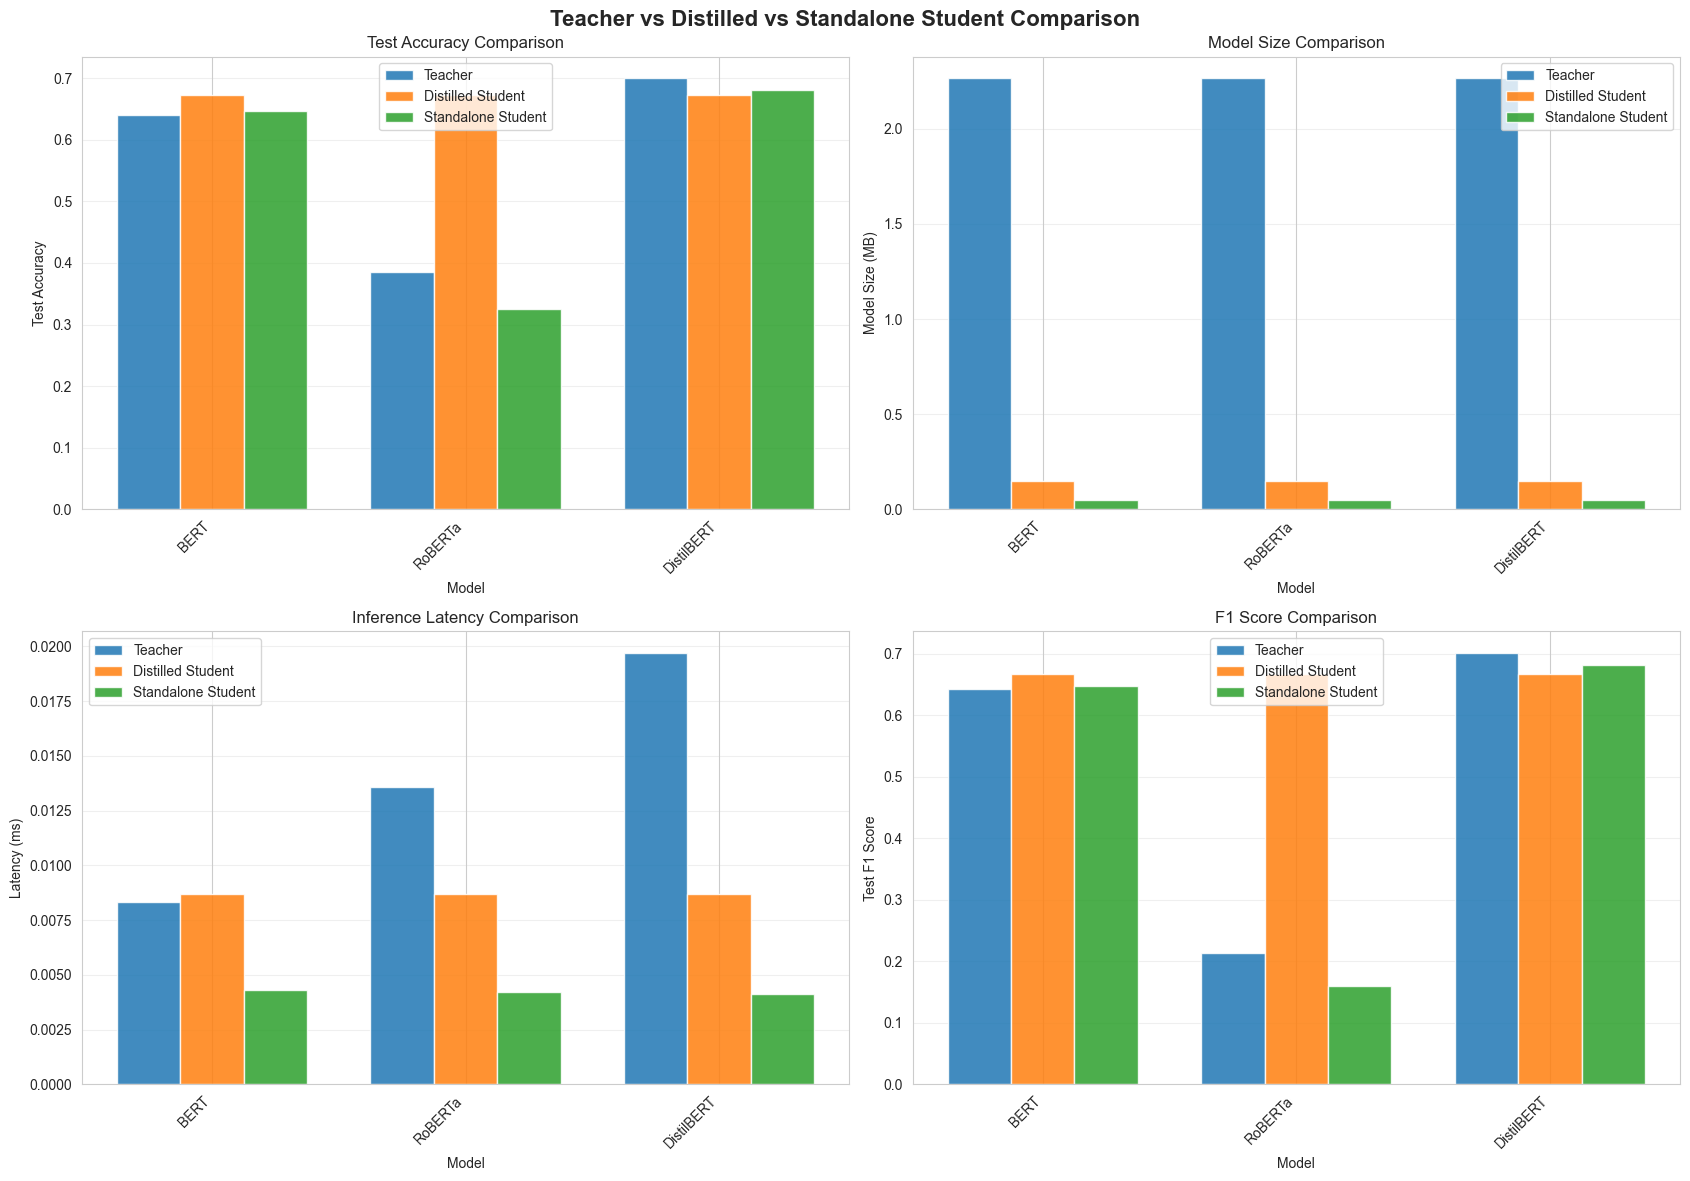

In [67]:
# Visualize Teacher vs Distilled Student vs Standalone Student comparison
fig, axes = plt.subplots(2, 2, figsize=(17, 12))
fig.suptitle('Teacher vs Distilled vs Standalone Student Comparison', fontsize=16, fontweight='bold')

model_names = list(final_results.keys())
x_pos = np.arange(len(model_names))
width = 0.25

# 1. Accuracy Comparison
teacher_accs = [final_results[m]['test_acc'] for m in model_names]
distilled_accs = [distillation_results[m]['test_acc'] for m in model_names]
standalone_accs = [standalone_results[m]['test_acc'] for m in model_names]

axes[0, 0].bar(x_pos - width, teacher_accs, width, label='Teacher', alpha=0.85)
axes[0, 0].bar(x_pos, distilled_accs, width, label='Distilled Student', alpha=0.85)
axes[0, 0].bar(x_pos + width, standalone_accs, width, label='Standalone Student', alpha=0.85)
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Model Size Comparison
teacher_sizes = [final_results[m]['size_mb'] for m in model_names]
distilled_sizes = [distillation_results[m]['size_mb'] for m in model_names]
standalone_sizes = [standalone_results[m]['size_mb'] for m in model_names]

axes[0, 1].bar(x_pos - width, teacher_sizes, width, label='Teacher', alpha=0.85)
axes[0, 1].bar(x_pos, distilled_sizes, width, label='Distilled Student', alpha=0.85)
axes[0, 1].bar(x_pos + width, standalone_sizes, width, label='Standalone Student', alpha=0.85)
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('Model Size (MB)')
axes[0, 1].set_title('Model Size Comparison')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(model_names, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Latency Comparison
teacher_latencies = [final_results[m]['latency_ms'] for m in model_names]
distilled_latencies = [distillation_results[m]['latency_ms'] for m in model_names]
standalone_latencies = [standalone_results[m]['latency_ms'] for m in model_names]

axes[1, 0].bar(x_pos - width, teacher_latencies, width, label='Teacher', alpha=0.85)
axes[1, 0].bar(x_pos, distilled_latencies, width, label='Distilled Student', alpha=0.85)
axes[1, 0].bar(x_pos + width, standalone_latencies, width, label='Standalone Student', alpha=0.85)
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('Latency (ms)')
axes[1, 0].set_title('Inference Latency Comparison')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(model_names, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. F1 Score Comparison
teacher_f1s = [final_results[m]['test_f1'] for m in model_names]
distilled_f1s = [distillation_results[m]['test_f1'] for m in model_names]
standalone_f1s = [standalone_results[m]['test_f1'] for m in model_names]

axes[1, 1].bar(x_pos - width, teacher_f1s, width, label='Teacher', alpha=0.85)
axes[1, 1].bar(x_pos, distilled_f1s, width, label='Distilled Student', alpha=0.85)
axes[1, 1].bar(x_pos + width, standalone_f1s, width, label='Standalone Student', alpha=0.85)
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('Test F1 Score')
axes[1, 1].set_title('F1 Score Comparison')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

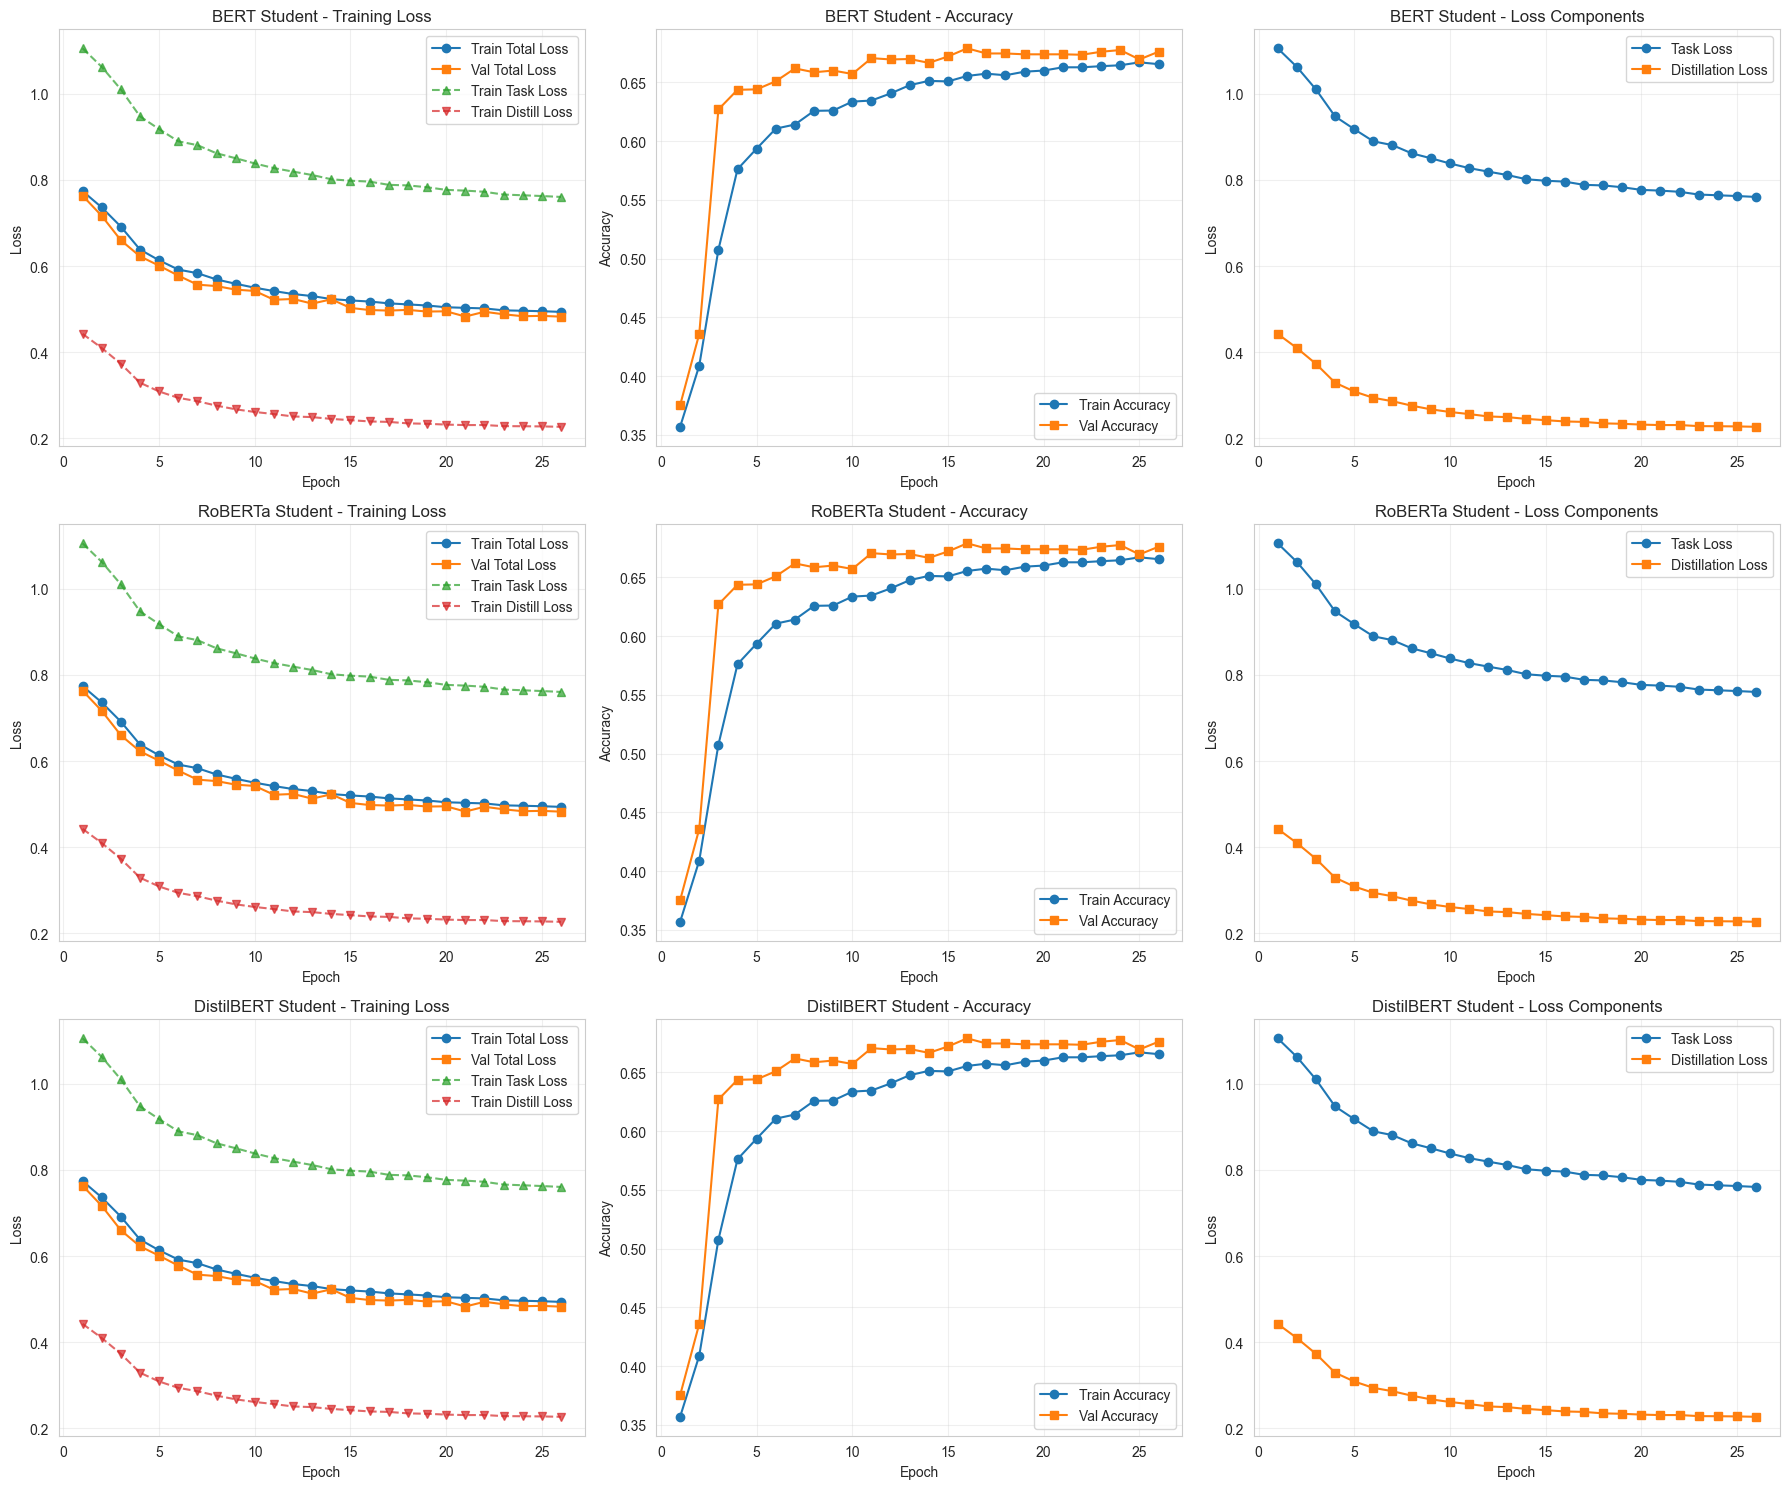

In [68]:
# Plot distillation training history for each student model
fig, axes = plt.subplots(len(model_names), 3, figsize=(18, 5 * len(model_names)))

if len(model_names) == 1:
    axes = axes.reshape(1, -1)

for idx, model_name in enumerate(model_names):
    history = distillation_results[model_name]['history']
    df_history = pd.DataFrame(history)
    
    # Loss plot
    axes[idx, 0].plot(df_history['epoch'], df_history['train_loss'], label='Train Total Loss', marker='o')
    axes[idx, 0].plot(df_history['epoch'], df_history['val_loss'], label='Val Total Loss', marker='s')
    axes[idx, 0].plot(df_history['epoch'], df_history['train_task_loss'], label='Train Task Loss', marker='^', linestyle='--', alpha=0.7)
    axes[idx, 0].plot(df_history['epoch'], df_history['train_distill_loss'], label='Train Distill Loss', marker='v', linestyle='--', alpha=0.7)
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].set_title(f'{model_name} Student - Training Loss')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[idx, 1].plot(df_history['epoch'], df_history['train_acc'], label='Train Accuracy', marker='o')
    axes[idx, 1].plot(df_history['epoch'], df_history['val_acc'], label='Val Accuracy', marker='s')
    axes[idx, 1].set_xlabel('Epoch')
    axes[idx, 1].set_ylabel('Accuracy')
    axes[idx, 1].set_title(f'{model_name} Student - Accuracy')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)
    
    # Loss components breakdown
    axes[idx, 2].plot(df_history['epoch'], df_history['train_task_loss'], label='Task Loss', marker='o')
    axes[idx, 2].plot(df_history['epoch'], df_history['train_distill_loss'], label='Distillation Loss', marker='s')
    axes[idx, 2].set_xlabel('Epoch')
    axes[idx, 2].set_ylabel('Loss')
    axes[idx, 2].set_title(f'{model_name} Student - Loss Components')
    axes[idx, 2].legend()
    axes[idx, 2].grid(True, alpha=0.3)

plt.tight_layout()
# distill_plot_path = os.path.join(MULTI_TEACHER_PLOTS_DIR, 'distillation_training_history.png')
# plt.savefig(distill_plot_path, dpi=300, bbox_inches='tight')
# print(f"Saved distillation training history plot to: {distill_plot_path}")
plt.show()

In [69]:
# Save distilled and standalone student results to CSV (optional)
distillation_csv_path = "feature_distillation_results.csv"
# comparison_df.to_csv(distillation_csv_path, index=False)
# print(f"Saved comparison results to {distillation_csv_path}")

# Save detailed distilled student results
detailed_distillation = []
for model_name, results in distillation_results.items():
    row = {'model': f'{model_name}_distilled'}
    row.update(results['config'])
    row.update({k: v for k, v in results.items() if k not in ['config', 'history']})
    detailed_distillation.append(row)

detailed_distill_df = pd.DataFrame(detailed_distillation)
detailed_distill_csv_path = "feature_distillation_detailed_results.csv"
# detailed_distill_df.to_csv(detailed_distill_csv_path, index=False)
# print(f"Saved detailed distilled student results to {detailed_distill_csv_path}")

# Save detailed standalone student results
detailed_standalone = []
for model_name, results in standalone_results.items():
    row = {'model': f'{model_name}_standalone'}
    row.update(results['config'])
    row.update({k: v for k, v in results.items() if k not in ['config', 'history']})
    detailed_standalone.append(row)

detailed_standalone_df = pd.DataFrame(detailed_standalone)
detailed_standalone_csv_path = "standalone_student_detailed_results.csv"
# detailed_standalone_df.to_csv(detailed_standalone_csv_path, index=False)
# print(f"Saved detailed standalone student results to {detailed_standalone_csv_path}")

# Save training histories for each model
distill_metrics_dir = "multi_teacher_distillation_metrics"
os.makedirs(distill_metrics_dir, exist_ok=True)

for model_name, results in distillation_results.items():
    history_df = pd.DataFrame(results['history'])
    # history_path = os.path.join(distill_metrics_dir, f"{model_name}_distillation_history.csv")
    # history_df.to_csv(history_path, index=False)

for model_name, results in standalone_results.items():
    history_df = pd.DataFrame(results['history'])
    # history_path = os.path.join(distill_metrics_dir, f"{model_name}_standalone_history.csv")
    # history_df.to_csv(history_path, index=False)

# print("\nAll student results prepared for export!")

## 13. Duration

In [106]:
# print the duration calculated
print(f"\nTotal notebook execution time: {duration}")


Total notebook execution time: 0:14:23.565351
